# Ordinal (cumulative-link) regression — detrended re-fit

This notebook refits the cumulative-link (ordered logit) regression models for frog call intensity using the *same detrending approach and plotting style* as `data_analysis_df2020.ipynb`.

We fit, for each species:
1. A model using **all available hours**.
2. A model using only the **expected calling window** for that species, defined by **season (day-of-year)** and **time-of-day**.

### Model covariates (no lags)
For each observation hour we include:
- Temperature (detrended)
- Relative Humidity (detrended)
- Time of day (cyclic Fourier terms)
- Day of year (cyclic Fourier terms)
- Whether the **other** species is currently calling ($>0$) (no lags)

### Key outputs
- Coefficient summaries
- Clear prediction curves and heatmaps
- Comparison of all-data vs expected-window fits
- Plots are saved as PDF (and SVG) into a `plots_ordinal_detrended` folder

## 0. Setup & configuration

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import warnings

from patsy import dmatrix
from statsmodels.miscmodels.ordinal_model import OrderedModel

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.set_printoptions(linewidth=150)
pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)

# ── Plot style (copied/adapted from data_analysis_df2020.ipynb) ─────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": True,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

COLORS = {
    "gastro": "#1f77b4",
    "oreo": "#ff7f0e",
    "both": "#2ca02c",
    "temp": "#d62728",
    "rh": "#9467bd",
}

SPECIES = ["Gastrotheca chrysosticta", "Oreobates berdemenos"]
SP_SHORT = {
    "Gastrotheca chrysosticta": "G. chrysosticta",
    "Oreobates berdemenos": "O. berdemenos",
}
SP_COLOR = {
    "Gastrotheca chrysosticta": COLORS["gastro"],
    "Oreobates berdemenos": COLORS["oreo"],
}

PLOT_DIR = Path("plots_ordinal")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name, formats=("pdf", "svg")):
    """Save figure in requested formats with tight bbox."""
    for fmt in formats:
        fig.savefig(PLOT_DIR / f"{name}.{fmt}", bbox_inches="tight")
    print(f"  ✓ Saved: {name}.pdf / .svg")

print("Setup complete. Plots will be saved to:", PLOT_DIR.resolve())

Setup complete. Plots will be saved to: /Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/arunan/Coding/yungas_aruna/Gastros_helechos/Granger_causality/plots_ordinal


## 1. Load data

In [26]:
# Path used in the existing notebooks
PT_drive = "/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/arunan/Martin_google_drive"
DATA_PATH = f"{PT_drive}/df_helechos_with2020.csv"

df = pd.read_csv(DATA_PATH)
df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")
df = df.set_index("DateTime").sort_index()

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
df.head()

Shape: (13257, 8)
Date range: 2018-09-02 00:00:00 → 2020-07-18 23:00:00


,Date,Month,Day,hour,Temp,RH%,Gastrotheca chrysosticta,Oreobates berdemenos
DateTime,,,,,,,,
2018-09-02 00:00:00,2018-09-02,9,245,0,4.553,100.0,0,0
2018-09-02 01:00:00,2018-09-02,9,245,1,4.051,100.0,0,0
2018-09-02 02:00:00,2018-09-02,9,245,2,4.553,100.0,0,0
2018-09-02 03:00:00,2018-09-02,9,245,3,3.550,100.0,0,0
2018-09-02 04:00:00,2018-09-02,9,245,4,3.048,100.0,0,0


## 2. Basic cleaning + core time features

In [27]:
# Ensure required columns exist
required_cols = SPECIES + ["Temp", "RH%"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Time features (hour and day-of-year). Month is sometimes already present; derive if missing.
df = df.copy()
df["hour"] = df.index.hour
df["doy"] = df.index.dayofyear
df["Month"] = df.get("Month", df.index.month)

# Drop obviously bad timestamps
df = df.loc[df.index.notna()].copy()

# Coerce to numeric where needed
for c in required_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(df[required_cols].isna().sum())

Gastrotheca chrysosticta       0
Oreobates berdemenos           0
Temp                           0
RH%                         1954
dtype: int64


## 3. Detrending (season + diurnal structure)
The goal here is to estimate *weather effects beyond time-of-day and day-of-year*. A rolling mean helps with slow drift, but it doesn’t cleanly remove the **cyclic** structure you later include in the model (hour-of-day + day-of-year).

So, in this refit we use a regression-based detrending that mirrors the modeling approach itself:

- Build a small seasonal/diurnal design matrix using Fourier terms for **hour** and **day-of-year** (1st + 2nd harmonics).
- For each series (Temp, RH%, and *each species’ call intensity*), regress it on those Fourier terms.
- Use the **residuals** as the detrended (anomaly) series.

This keeps interpretation consistent: a positive detrended value means "higher than expected given the time of day + season".

Practical notes:
- We detrend the *calls* too (requested), so later analyses can cleanly attribute effects to weather / interaction rather than baked-in seasonality.
- RH% has missingness after ~Jan 2020; all residualization uses whatever rows are available for that variable.

In [4]:
# Fourier residualization detrending (for Temp, RH%, and calls)
two_pi = 2 * np.pi

def _fourier_df(index: pd.DatetimeIndex) -> pd.DataFrame:
    hour = index.hour.astype(float)
    doy = index.dayofyear.astype(float)
    return pd.DataFrame({
        "sin_h1": np.sin(two_pi * hour / 24.0),
        "cos_h1": np.cos(two_pi * hour / 24.0),
        "sin_h2": np.sin(2 * two_pi * hour / 24.0),
        "cos_h2": np.cos(2 * two_pi * hour / 24.0),
        "sin_d1": np.sin(two_pi * doy / 366.0),
        "cos_d1": np.cos(two_pi * doy / 366.0),
        "sin_d2": np.sin(2 * two_pi * doy / 366.0),
        "cos_d2": np.cos(2 * two_pi * doy / 366.0),
    }, index=index)

def detrend_by_fourier(series: pd.Series) -> pd.DataFrame:
    """Return trend (= fitted seasonal/diurnal mean) and detrended residuals."""
    y = pd.to_numeric(series, errors="coerce")
    X = _fourier_df(y.index)
    m = pd.concat([y.rename("y"), X], axis=1).dropna()
    if len(m) < 20:
        return pd.DataFrame({"trend": np.nan, "detr": np.nan}, index=y.index)
    # OLS via np.linalg.lstsq (keeps deps light; intercept is redundant with Fourier but OK)
    Xn = np.column_stack([np.ones(len(m)), m[X.columns].to_numpy()])
    beta, *_ = np.linalg.lstsq(Xn, m["y"].to_numpy(), rcond=None)
    yhat = Xn @ beta
    trend = pd.Series(index=m.index, data=yhat)
    detr = m["y"] - trend
    out = pd.DataFrame(index=y.index, data={"trend": np.nan, "detr": np.nan})
    out.loc[m.index, "trend"] = trend
    out.loc[m.index, "detr"] = detr
    return out

# Apply to env covariates and both call series
for c in ["Temp", "RH%", "Gastrotheca chrysosticta", "Oreobates berdemenos"]:
    out = detrend_by_fourier(df[c])
    df[f"{c}_trend"] = out["trend"]
    df[f"{c}_detr"] = out["detr"]

# Convenience renamed columns used later
df["Temp_detr"] = df["Temp_detr"] if "Temp_detr" in df.columns else df["Temp_detr"]  # noop, readability
df["RH%_detr"] = df["RH%_detr"] if "RH%_detr" in df.columns else df["RH%_detr"]  # noop

df[["Temp", "Temp_trend", "Temp_detr", "RH%", "RH%_trend", "RH%_detr"]].head()

,Temp,Temp_trend,Temp_detr,RH%,RH%_trend,RH%_detr
DateTime,,,,,,
2018-09-02 00:00:00,4.553,13.228043,-8.675043,100.0,77.833737,22.166263
2018-09-02 01:00:00,4.051,13.103344,-9.052344,100.0,77.836686,22.163314
2018-09-02 02:00:00,4.553,12.965076,-8.412076,100.0,77.723035,22.276965
2018-09-02 03:00:00,3.550,12.765569,-9.215569,100.0,77.743170,22.256830
2018-09-02 04:00:00,3.048,12.501548,-9.453548,100.0,78.033415,21.966585


  ✓ Saved: 01_detrending_check_temp.pdf / .svg


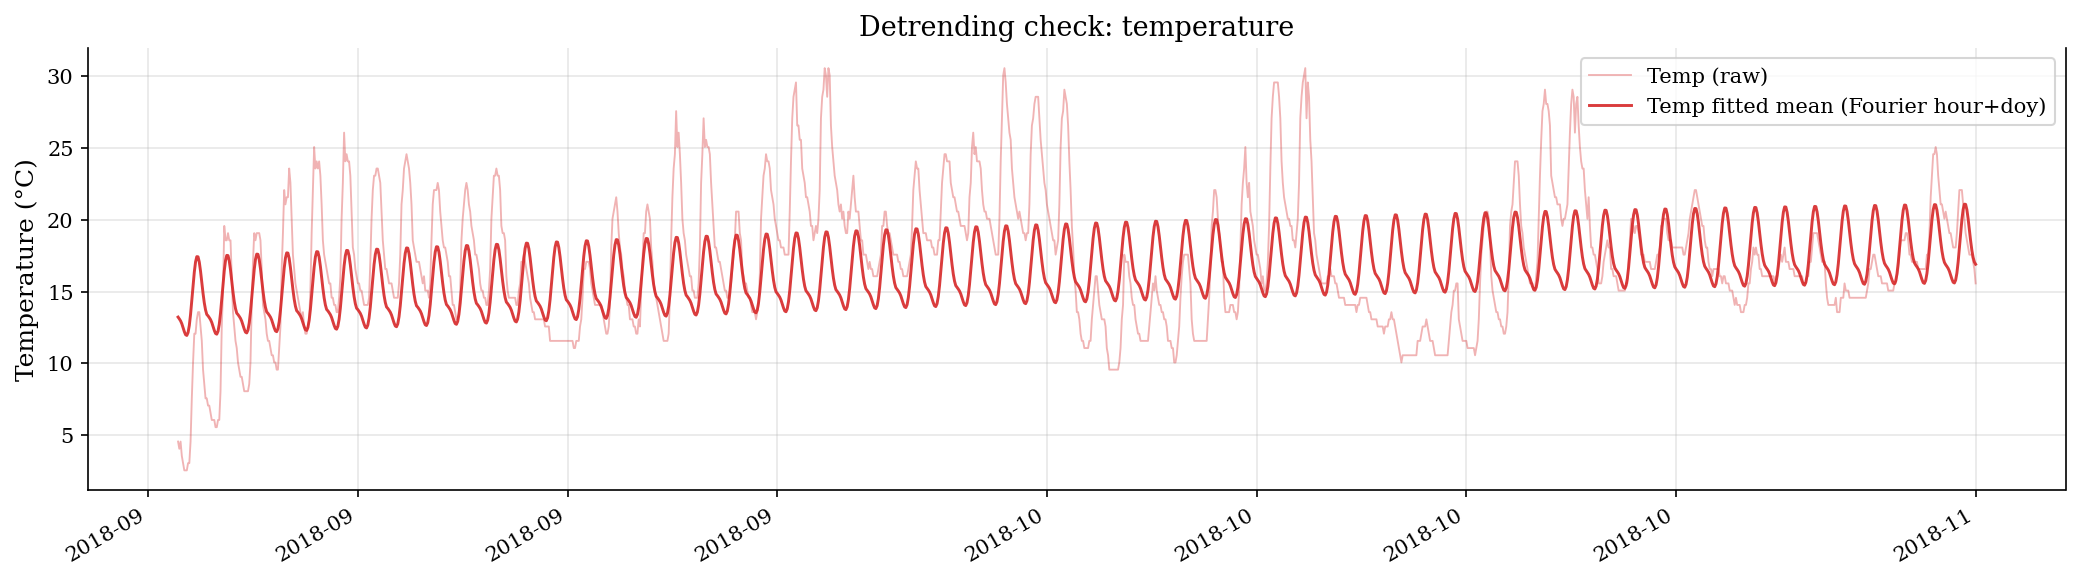

In [5]:
# Quick sanity plot for detrending (Fourier seasonal/diurnal fit)
start, end = df.index.min(), df.index.min() + pd.Timedelta(days=60)
sub = df.loc[start:end].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sub.index, sub["Temp"], color=COLORS["temp"], alpha=0.35, linewidth=0.9, label="Temp (raw)")
ax.plot(sub.index, sub["Temp_trend"], color=COLORS["temp"], alpha=0.9, linewidth=1.4, label="Temp fitted mean (Fourier hour+doy)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Detrending check: temperature")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
fig.tight_layout()
savefig(fig, "01_detrending_check_temp")
plt.show()

## 4. Expected calling windows (season × time of day)
We define a *simple, data-driven* expected calling window for each species using the observed probability of calling ($>0$) across (day-of-year, hour).

Steps:
1. Compute a heatmap of $P("calling")$ for each species.
2. Smooth across day-of-year with a short rolling mean.
3. Define the expected window as the set of (doy, hour) bins where calling probability exceeds a threshold.

This is meant to emulate the seasonality exploration done in `data_analysis_df2020` while giving a reproducible mask for subsetting.

In [34]:
# Identify periods with no calls from either species
no_calls = (df["Gastrotheca chrysosticta"] == 0) & (df["Oreobates berdemenos"] == 0)

# Create a rolling sum over 2 days (in hours)
no_calls_rolling = no_calls.rolling(window=72, min_periods=1).sum()

# Filter out records where the rolling sum equals 48 (indicating no calls for 3 days)
df_filtered = df[no_calls_rolling < 72]
print(f"Original records: {len(df):,}")
print(f"Filtered records: {len(df_filtered):,}")

# Filter out records between 10:00 and 17:00 (no calls in daytime so ignore anyway)?
df_filtered_hr = df_filtered[(df_filtered['hour']<10) | (df_filtered['hour']>17)]
print(f"Original records: {len(df):,}")
print(f"Filtered records : {len(df_filtered_hr):,}")
# print number of records with calls removed
print(f"Records removed by no-call filter: {len(df) - len(df_filtered):,}")
print(f"Records removed by daytime filter: {len(df_filtered) - len(df_filtered_hr):,}")

Original records: 13,257
Filtered records: 9,702
Original records: 13,257
Filtered records : 6,469
Records removed by no-call filter: 3,555
Records removed by daytime filter: 3,233


  ✓ Saved: 04_daily_smoothed_timeseries.pdf / .svg


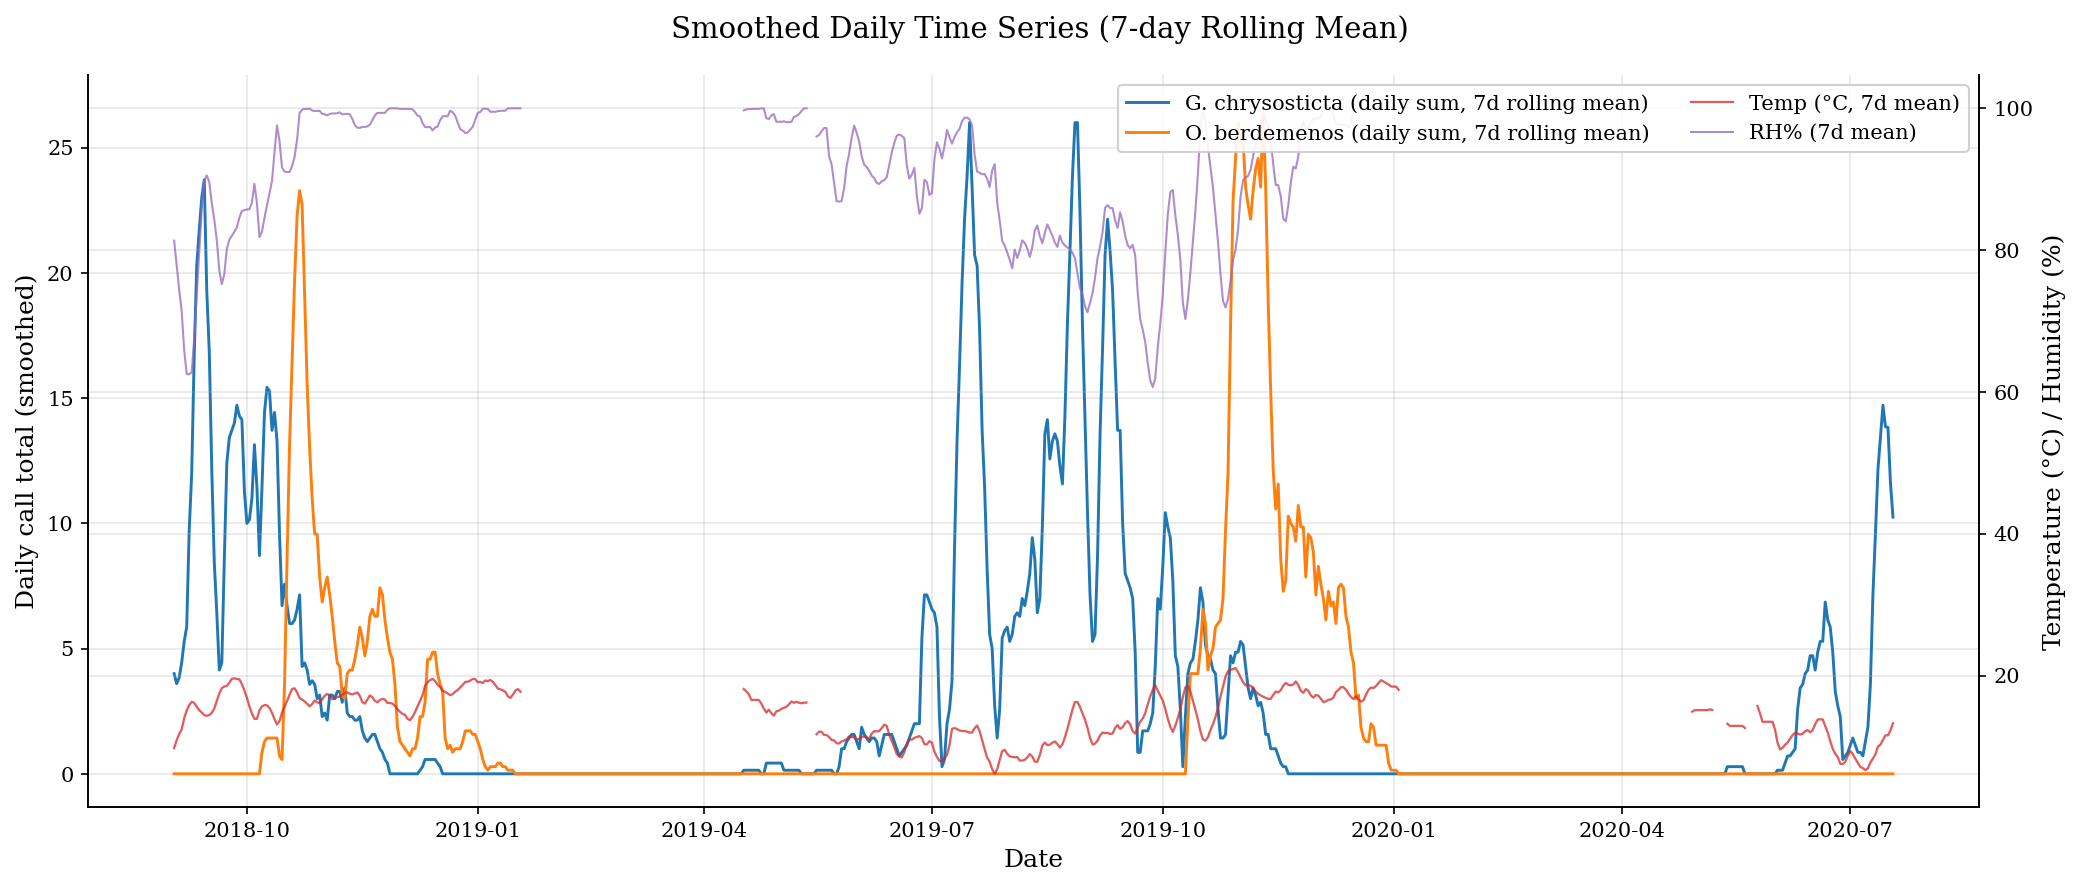

In [35]:
# ── Smoothed daily time series ───────────────────────────────────────────────
# Sum calls per day, mean weather per day, then apply n-day rolling mean
daily_calls = df_filtered_hr[SPECIES].resample("D").sum()
daily_weather = df_filtered_hr[["Temp", "RH%"]].resample("D").mean()
daily_all = daily_calls.join(daily_weather)

SMOOTH_WIN = 7  # days
daily_smooth = daily_all.rolling(SMOOTH_WIN, center=True, min_periods=1).mean()
# daily_smooth = daily_all

fig_sm, ax_sm = plt.subplots(figsize=(14, 6))

# Calls (primary)
for sp in SPECIES:
    ax_sm.plot(daily_smooth.index, daily_smooth[sp],
               label=f"{SP_SHORT[sp]} (daily sum, {SMOOTH_WIN}d rolling mean)",
               color=SP_COLOR[sp], linewidth=1.4)
ax_sm.set_xlabel("Date")
ax_sm.set_ylabel("Daily call total (smoothed)")

# Weather (secondary)
ax_sm2 = ax_sm.twinx()
ax_sm2.plot(daily_smooth.index, daily_smooth["Temp"],
            color=COLORS["temp"], linewidth=1.1, alpha=0.75,
            label=f"Temp (°C, {SMOOTH_WIN}d mean)")
ax_sm2.plot(daily_smooth.index, daily_smooth["RH%"],
            color=COLORS["rh"], linewidth=1.0, alpha=0.75,
            label=f"RH% ({SMOOTH_WIN}d mean)")
ax_sm2.set_ylabel("Temperature (°C) / Humidity (%)")

# Combined legend
h1, l1 = ax_sm.get_legend_handles_labels()
h2, l2 = ax_sm2.get_legend_handles_labels()
ax_sm2.legend(h1 + h2, l1 + l2, loc="upper right", ncol=2, framealpha=0.9)

fig_sm.suptitle(f"Smoothed Daily Time Series ({SMOOTH_WIN}-day Rolling Mean)", fontsize=14)
fig_sm.tight_layout()
savefig(fig_sm, "04_daily_smoothed_timeseries")
plt.show()

  ✓ Saved: 05_hourly_mean_profile.pdf / .svg


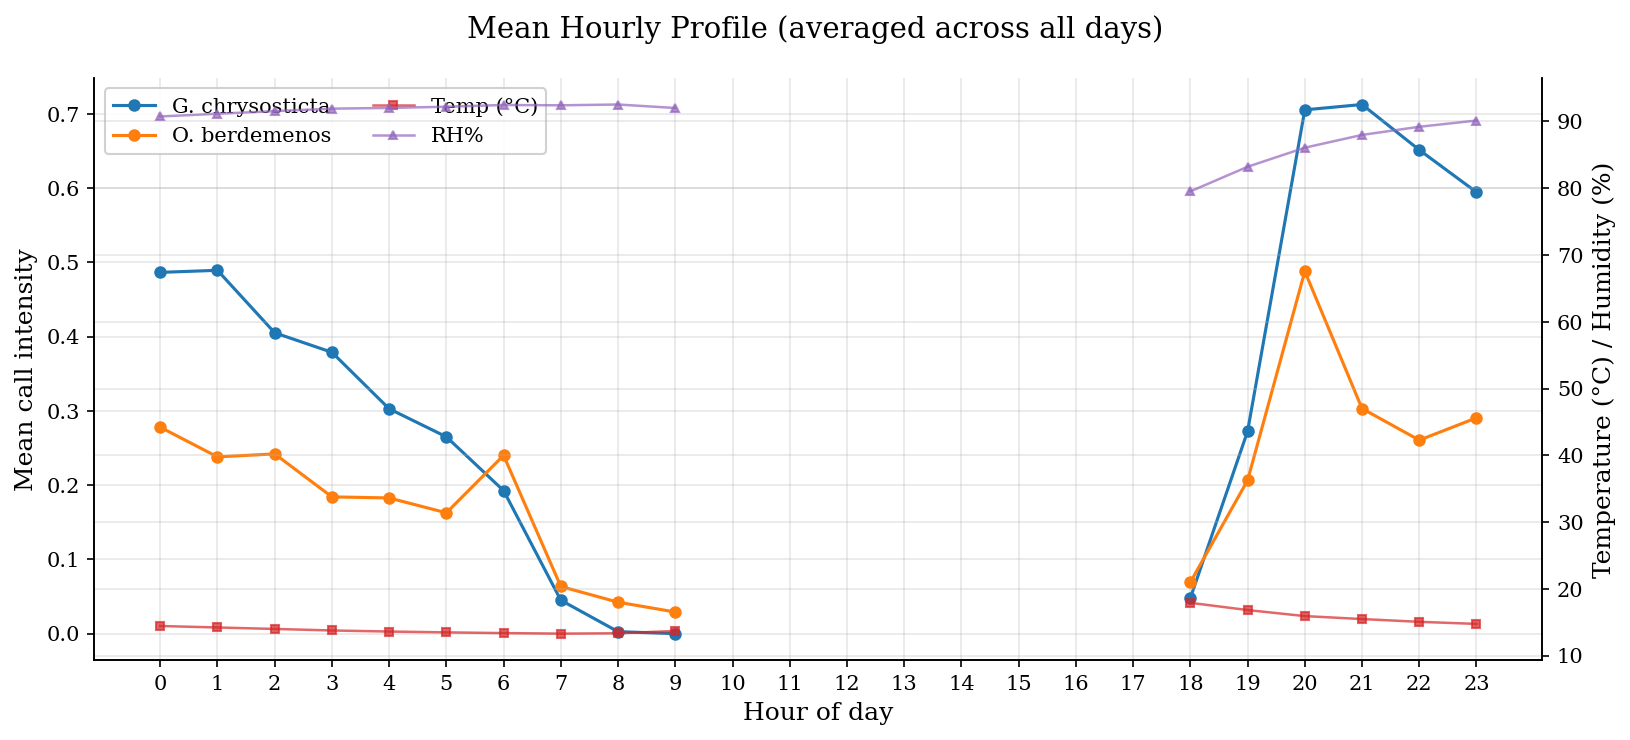

In [21]:
# ── 3a. Mean call intensity per hour-of-day ─────────────────────────────────
# Average (mean) of each variable over all days, grouped by hour.
hourly_mean = df_filtered_hr.groupby("hour")[SPECIES + ["Temp", "RH%"]].mean().reindex(range(24))

fig_hm, ax_hm = plt.subplots(figsize=(11, 5))

for sp in SPECIES:
    ax_hm.plot(hourly_mean.index, hourly_mean[sp],
               marker="o", ms=5, label=SP_SHORT[sp], color=SP_COLOR[sp], linewidth=1.5)
ax_hm.set_xlabel("Hour of day")
ax_hm.set_ylabel("Mean call intensity")
ax_hm.set_xticks(range(24))

# Weather on secondary axis
ax_hm2 = ax_hm.twinx()
ax_hm2.plot(hourly_mean.index, hourly_mean["Temp"],
            marker="s", ms=4, color=COLORS["temp"], linewidth=1.2, alpha=0.7, label="Temp (°C)")
ax_hm2.plot(hourly_mean.index, hourly_mean["RH%"],
            marker="^", ms=4, color=COLORS["rh"], linewidth=1.2, alpha=0.7, label="RH%")
ax_hm2.set_ylabel("Temperature (°C) / Humidity (%)")

h1, l1 = ax_hm.get_legend_handles_labels()
h2, l2 = ax_hm2.get_legend_handles_labels()
ax_hm.legend(h1 + h2, l1 + l2, loc="upper left", ncol=2, framealpha=0.9)

fig_hm.suptitle("Mean Hourly Profile (averaged across all days)", fontsize=14)
fig_hm.tight_layout()
savefig(fig_hm, "05_hourly_mean_profile")
plt.show()

In [6]:
CALL_THRESHOLD = 0.15   # probability threshold for 'expected calling'
DOY_SMOOTH_WIN = 9      # smooth across day-of-year (bins), about ~9 days

def expected_call_mask(df_in: pd.DataFrame, sp_col: str, thresh: float = 0.15, doy_smooth: int = 9):
    tmp = df_in[[sp_col, "doy", "hour"]].dropna().copy()
    tmp["calling"] = (tmp[sp_col] > 0).astype(int)
    # P(call) in each (doy, hour)
    grid = tmp.pivot_table(values="calling", index="doy", columns="hour", aggfunc="mean")
    grid = grid.reindex(index=range(1, 367), columns=range(24))
    # Smooth along day-of-year
    grid_s = grid.rolling(window=doy_smooth, center=True, min_periods=max(3, doy_smooth//3)).mean()
    # Define expected calls
    expected_grid = (grid_s >= thresh)

    # Map each row to expected?
    # (clip doy to 1..366, hour to 0..23)
    doy_i = df_in["doy"].clip(1, 366).astype(int)
    hour_i = df_in["hour"].clip(0, 23).astype(int)
    expected_row = expected_grid.to_numpy()[doy_i.values - 1, hour_i.values]
    return expected_row, grid_s

expected_gastro, gastro_grid_p = expected_call_mask(df, "Gastrotheca chrysosticta", thresh=CALL_THRESHOLD, doy_smooth=DOY_SMOOTH_WIN)
expected_oreo, oreo_grid_p = expected_call_mask(df, "Oreobates berdemenos", thresh=CALL_THRESHOLD, doy_smooth=DOY_SMOOTH_WIN)

df["expected_gastro"] = expected_gastro
df["expected_oreo"] = expected_oreo

print(df[["expected_gastro", "expected_oreo"]].mean())

expected_gastro    0.202157
expected_oreo      0.126876
dtype: float64


  ✓ Saved: 02_expected_calling_heatmap_gastro.pdf / .svg


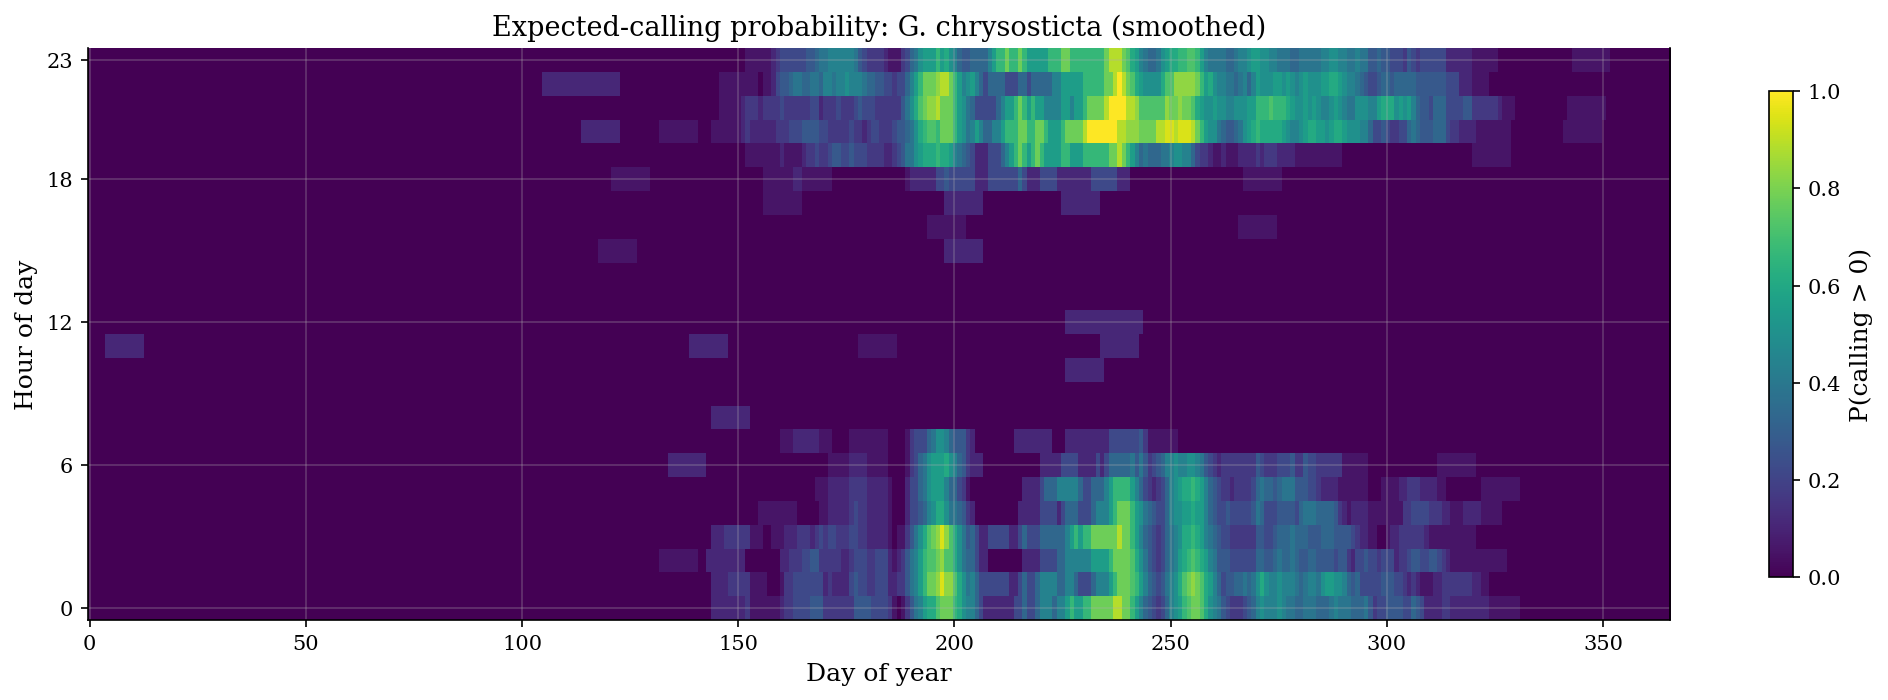

  ✓ Saved: 03_expected_calling_heatmap_oreo.pdf / .svg


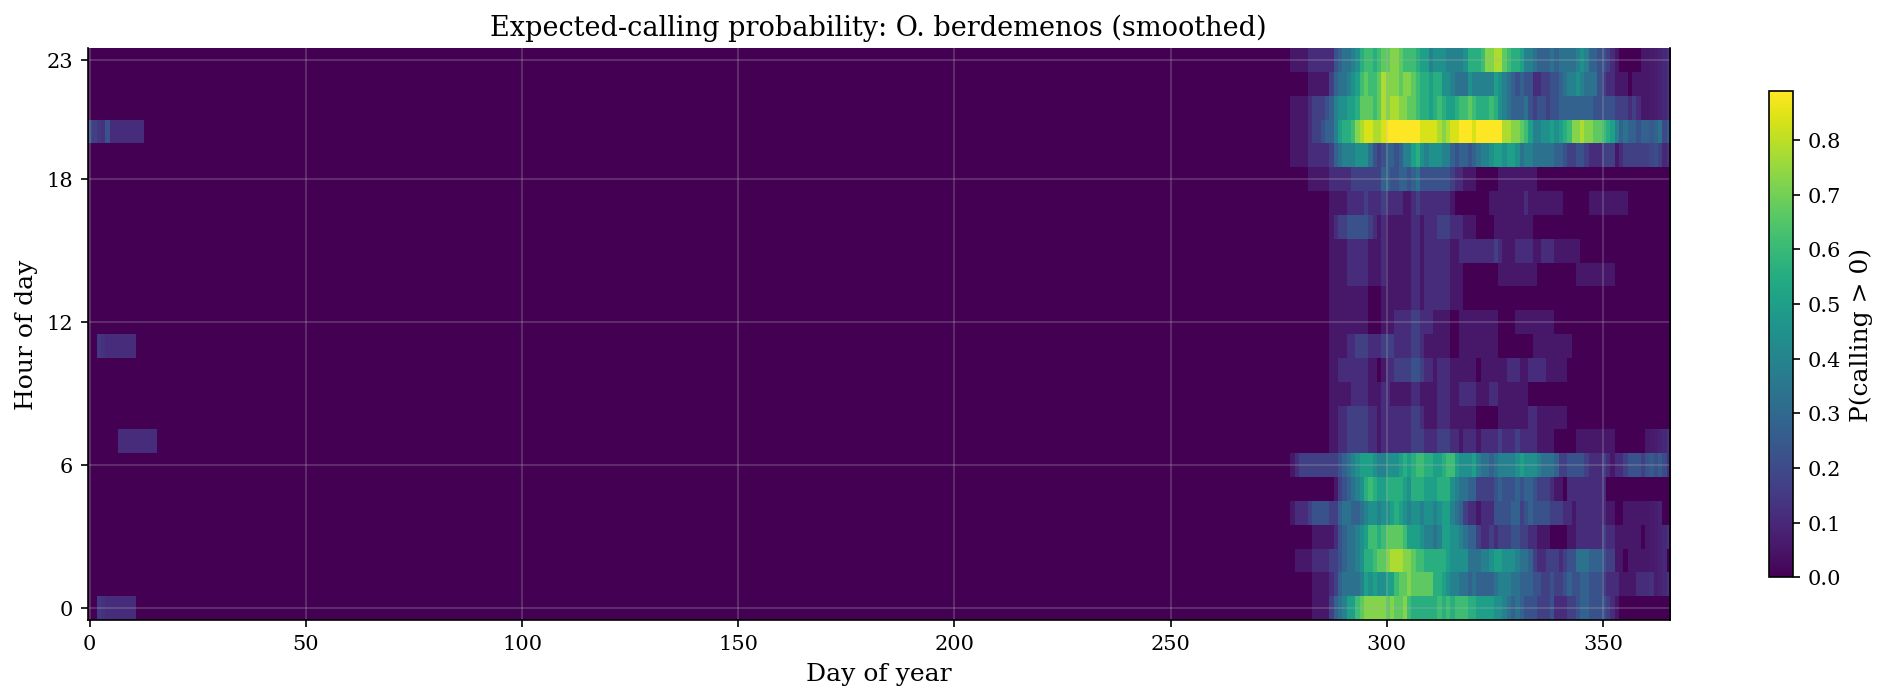

In [7]:
# Plot expected calling heatmaps (probability)
def plot_expected_heatmap(grid_p: pd.DataFrame, title: str, fname: str):
    fig, ax = plt.subplots(figsize=(14, 4.8))
    # grid_p has index doy(1..366), cols hour(0..23)
    im = ax.imshow(grid_p.T, aspect="auto", origin="lower", cmap="viridis")
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Hour of day")
    ax.set_title(title)
    cb = fig.colorbar(im, ax=ax, shrink=0.85)
    cb.set_label("P(calling > 0)")
    ax.set_yticks([0, 6, 12, 18, 23])
    ax.set_yticklabels([0, 6, 12, 18, 23])
    fig.tight_layout()
    savefig(fig, fname)
    plt.show()

plot_expected_heatmap(gastro_grid_p, f"Expected-calling probability: {SP_SHORT[SPECIES[0]]} (smoothed)", "02_expected_calling_heatmap_gastro")
plot_expected_heatmap(oreo_grid_p,   f"Expected-calling probability: {SP_SHORT[SPECIES[1]]} (smoothed)", "03_expected_calling_heatmap_oreo")

## 5. Feature engineering for ordinal models (no lags)
We use cyclic Fourier terms for hour-of-day and day-of-year (first + second harmonics), and we include a binary 
indicator that the other species is currently calling (no lag).

We also standardize detrended temperature and humidity (z-scores) to put them on comparable scales.

In [8]:
two_pi = 2 * np.pi

def add_fourier_terms(df_in: pd.DataFrame) -> pd.DataFrame:
    d = df_in.copy()
    # hour (period 24)
    d["sin_h1"] = np.sin(two_pi * d["hour"] / 24.0)
    d["cos_h1"] = np.cos(two_pi * d["hour"] / 24.0)
    d["sin_h2"] = np.sin(2 * two_pi * d["hour"] / 24.0)
    d["cos_h2"] = np.cos(2 * two_pi * d["hour"] / 24.0)

    # doy (period 366)
    d["sin_d1"] = np.sin(two_pi * d["doy"] / 366.0)
    d["cos_d1"] = np.cos(two_pi * d["doy"] / 366.0)
    d["sin_d2"] = np.sin(2 * two_pi * d["doy"] / 366.0)
    d["cos_d2"] = np.cos(2 * two_pi * d["doy"] / 366.0)
    return d

df = add_fourier_terms(df)

# Binary indicator: other species calling (no lag)
df["gastro_calling"] = (df["Gastrotheca chrysosticta"] > 0).astype(int)
df["oreo_calling"]   = (df["Oreobates berdemenos"] > 0).astype(int)

# Standardize detrended env covariates (z-score), computed on rows used for each fit later
# We keep raw detrended columns here; standardization happens inside fit function to avoid leakage between subsets.
df[["Temp_detr", "RH%_detr", "gastro_calling", "oreo_calling"]].describe()

,Temp_detr,RH%_detr,gastro_calling,oreo_calling
count,1.325700e+04,1.130300e+04,13257.000000,13257.000000
mean,-5.235409e-15,-6.895841e-14,0.086671,0.059139
std,3.573685e+00,1.224809e+01,0.281363,0.235893
min,-1.090459e+01,-6.468547e+01,0.000000,0.000000
25%,-2.424667e+00,-4.423591e+00,0.000000,0.000000
50%,-2.838135e-03,2.428542e-01,0.000000,0.000000
75%,2.287051e+00,8.190965e+00,0.000000,0.000000
max,1.709418e+01,3.449608e+01,1.000000,1.000000


## 6. Fit ordinal (ordered logit) models
We fit *two models per species* (all-data vs expected-calling window).

To keep the model interpretable and close to your earlier `Granger.ipynb` ordinal setup, we use:
- cubic B-splines for detrended temperature and humidity (non-linear effects),
- Fourier terms for diurnal and seasonal cycles,
- the other species calling indicator (no lags).

Note: For `statsmodels` `OrderedModel`, the cutpoints act like an intercept, so we use `0 + ...` in the Patsy design.

In [9]:
spline_formula = (
    "0 + bs(temp_detr_s, df=6, degree=3) + bs(rh_detr_s, df=6, degree=3) "
    "+ sin_h1 + cos_h1 + sin_h2 + cos_h2 "
    "+ sin_d1 + cos_d1 + sin_d2 + cos_d2 "
    "+ other_calling"
)

def prep_model_df(df_in: pd.DataFrame, y_col: str, other_call_col: str) -> pd.DataFrame:
    d = df_in.copy()
    # required for model
    needed = [y_col, "Temp_detr", "RH%_detr", "hour", "doy",
              "sin_h1", "cos_h1", "sin_h2", "cos_h2",
              "sin_d1", "cos_d1", "sin_d2", "cos_d2", other_call_col]
    d = d.dropna(subset=needed).copy()

    # Endog must be int categories 0..3
    d[y_col] = d[y_col].astype(int)

    # other_calling
    d["other_calling"] = d[other_call_col].astype(int)

    # Standardize detrended covariates within the subset (keeps all-data vs window comparable within its fit)
    tmu, tsd = d["Temp_detr"].mean(), d["Temp_detr"].std(ddof=0)
    rmu, rsd = d["RH%_detr"].mean(), d["RH%_detr"].std(ddof=0)
    d["temp_detr_s"] = (d["Temp_detr"] - tmu) / (tsd if tsd > 0 else 1.0)
    d["rh_detr_s"]   = (d["RH%_detr"] - rmu) / (rsd if rsd > 0 else 1.0)

    meta = {"temp_mu": float(tmu), "temp_sd": float(tsd if tsd > 0 else 1.0),
            "rh_mu": float(rmu), "rh_sd": float(rsd if rsd > 0 else 1.0)}
    return d, meta

def fit_ordered_logit(d: pd.DataFrame, y_col: str):
    X_proto = dmatrix(spline_formula, d, return_type="dataframe")
    design_info = X_proto.design_info
    X = dmatrix(design_info, d, return_type="dataframe")
    y = d[y_col].values
    mod = OrderedModel(endog=y, exog=X, distr="logit")
    res = mod.fit(method="bfgs", maxiter=2000, disp=False)
    return res, design_info

def fit_two_scopes(species: str):
    if species == "Gastrotheca chrysosticta":
        y_col = species
        expected_col = "expected_gastro"
        other_call_col = "oreo_calling"
    elif species == "Oreobates berdemenos":
        y_col = species
        expected_col = "expected_oreo"
        other_call_col = "gastro_calling"
    else:
        raise ValueError(species)

    # all rows
    d_all, meta_all = prep_model_df(df, y_col=y_col, other_call_col=other_call_col)
    res_all, di_all = fit_ordered_logit(d_all, y_col=y_col)

    # expected calling window
    d_win_src = df.loc[df[expected_col].astype(bool)].copy()
    d_win, meta_win = prep_model_df(d_win_src, y_col=y_col, other_call_col=other_call_col)
    res_win, di_win = fit_ordered_logit(d_win, y_col=y_col)

    return {
        "y_col": y_col,
        "expected_col": expected_col,
        "other_call_col": other_call_col,
        "all": {"res": res_all, "design": di_all, "df": d_all, "meta": meta_all},
        "win": {"res": res_win, "design": di_win, "df": d_win, "meta": meta_win},
    }

fits = {sp: fit_two_scopes(sp) for sp in SPECIES}
for sp in SPECIES:
    print("\n" + "="*90)
    print(sp, "(ALL DATA)")
    print(fits[sp]["all"]["res"].summary())
    print("\n" + sp, "(EXPECTED WINDOW)")
    print(fits[sp]["win"]["res"].summary())


Gastrotheca chrysosticta (ALL DATA)
                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -2539.9
Model:                   OrderedModel   AIC:                             5128.
Method:            Maximum Likelihood   BIC:                             5304.
Date:                Fri, 24 Apr 2026                                         
Time:                        14:49:11                                         
No. Observations:               11303                                         
Df Residuals:                   11279                                         
Df Model:                          21                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
bs(temp_detr_s, df=6, degree=3)[0]     7.1980 

## 7. Diagnostics: observed vs fitted category frequencies
A simple calibration check: compare the average predicted probability of each level with the observed proportions.

In [10]:
def calibration_table(res, design_info, d: pd.DataFrame, y_col: str):
    X = dmatrix(design_info, d, return_type="dataframe")
    probs = res.model.predict(res.params, exog=X, which="prob")
    probs_np = np.asarray(probs)
    pred_share = probs_np.mean(axis=0)
    obs_counts = d[y_col].value_counts().sort_index()
    obs_share = (obs_counts / obs_counts.sum()).reindex(range(probs_np.shape[1])).fillna(0).values
    out = pd.DataFrame({"category": range(probs_np.shape[1]),
                        "predicted_share": pred_share,
                        "observed_share": obs_share})
    return out

tabs = []
for sp in SPECIES:
    y_col = fits[sp]["y_col"]
    for scope in ["all", "win"]:
        res = fits[sp][scope]["res"]
        di = fits[sp][scope]["design"]
        d = fits[sp][scope]["df"]
        t = calibration_table(res, di, d, y_col=y_col)
        t["species"] = sp
        t["scope"] = scope
        tabs.append(t)

calib = pd.concat(tabs, ignore_index=True)
calib

,category,predicted_share,observed_share,species,scope
0,0,0.907360,0.910201,Gastrotheca chrysosticta,all
1,1,0.033886,0.033442,Gastrotheca chrysosticta,all
2,2,0.036300,0.033973,Gastrotheca chrysosticta,all
3,3,0.022454,0.022383,Gastrotheca chrysosticta,all
4,0,0.584204,0.594090,Gastrotheca chrysosticta,win
5,1,0.139914,0.139939,Gastrotheca chrysosticta,win
6,2,0.165234,0.156888,Gastrotheca chrysosticta,win
7,3,0.110648,0.109083,Gastrotheca chrysosticta,win
8,0,0.931354,0.931965,Oreobates berdemenos,all
9,1,0.026763,0.026984,Oreobates berdemenos,all


  ✓ Saved: 04_calibration_gastrotheca.pdf / .svg


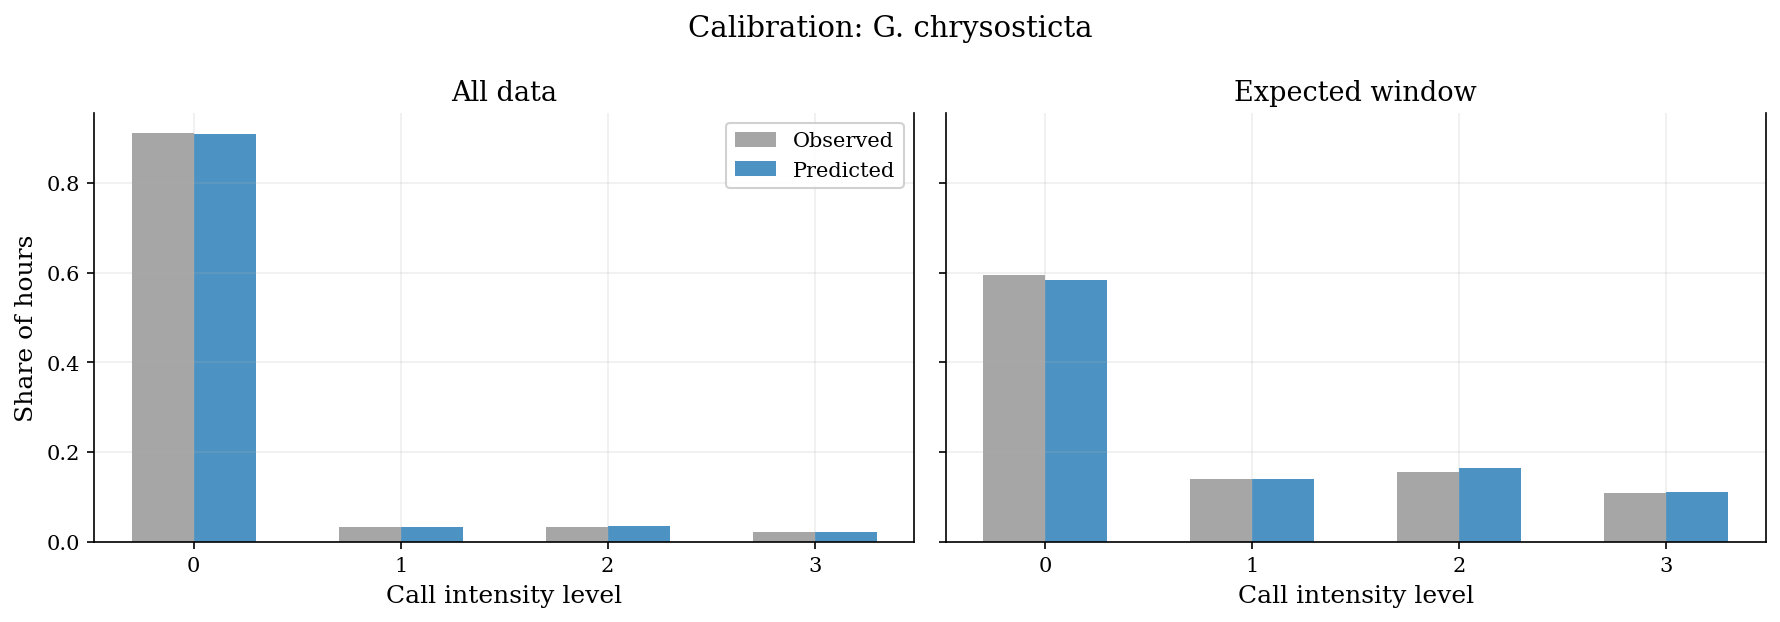

  ✓ Saved: 04_calibration_oreobates.pdf / .svg


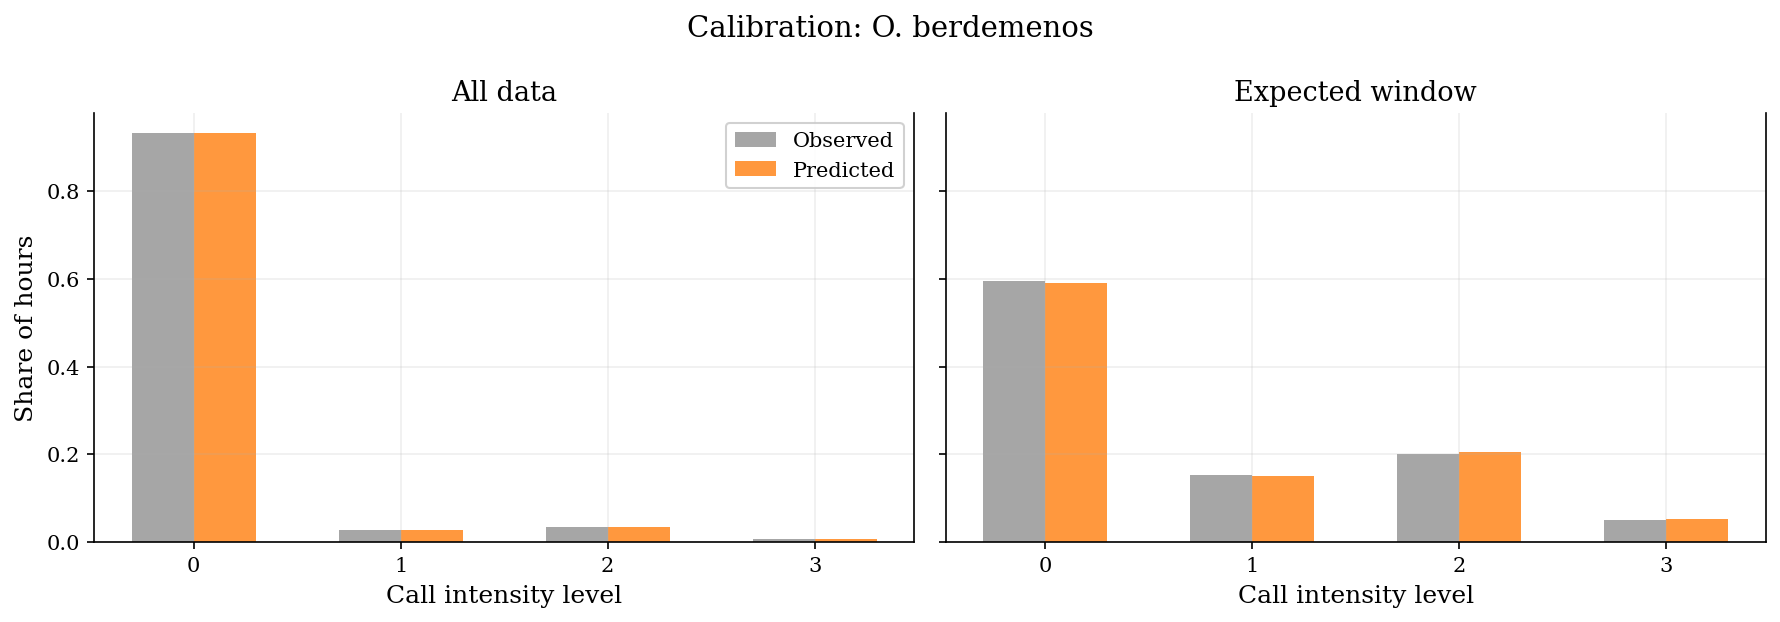

In [11]:
# Plot calibration bars
for sp in SPECIES:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
    for ax, scope, ttl in zip(axes, ["all", "win"], ["All data", "Expected window"]):
        dd = calib[(calib["species"] == sp) & (calib["scope"] == scope)].sort_values("category")
        x = dd["category"].values
        ax.bar(x - 0.15, dd["observed_share"], width=0.3, label="Observed", color="gray", alpha=0.7)
        ax.bar(x + 0.15, dd["predicted_share"], width=0.3, label="Predicted", color=SP_COLOR[sp], alpha=0.8)
        ax.set_title(ttl)
        ax.set_xlabel("Call intensity level")
        ax.set_xticks([0, 1, 2, 3])
        ax.grid(alpha=0.2)
    axes[0].set_ylabel("Share of hours")
    axes[0].legend(framealpha=0.9)
    fig.suptitle(f"Calibration: {SP_SHORT[sp]}", fontsize=14)
    fig.tight_layout()
    savefig(fig, f"04_calibration_{sp.split()[0].lower()}")
    plt.show()

## 8. Prediction curves
We plot predicted category probabilities and expected call level as a function of detrended temperature / humidity, holding season/time fixed.

Because we used *detrended* covariates, these curves should be interpreted as **the effect of being warmer/cooler or wetter/drier than the local seasonal mean**, not absolute temperature/humidity.

  ✓ Saved: 05_curve_temp_gastrotheca_all_other0.pdf / .svg


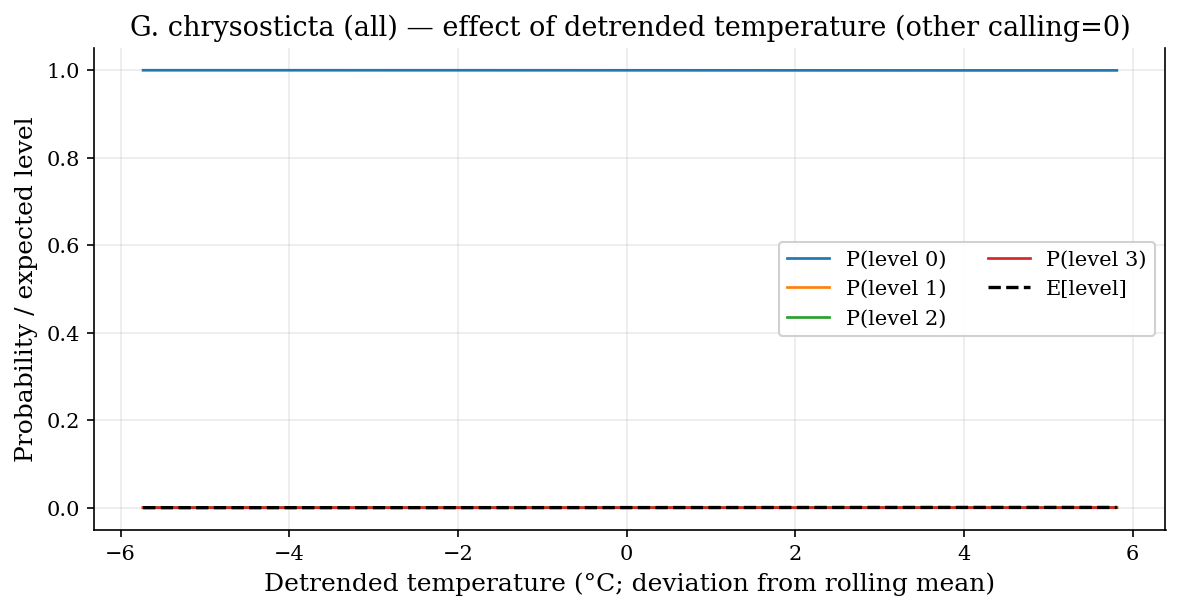

  ✓ Saved: 06_curve_rh_gastrotheca_all_other0.pdf / .svg


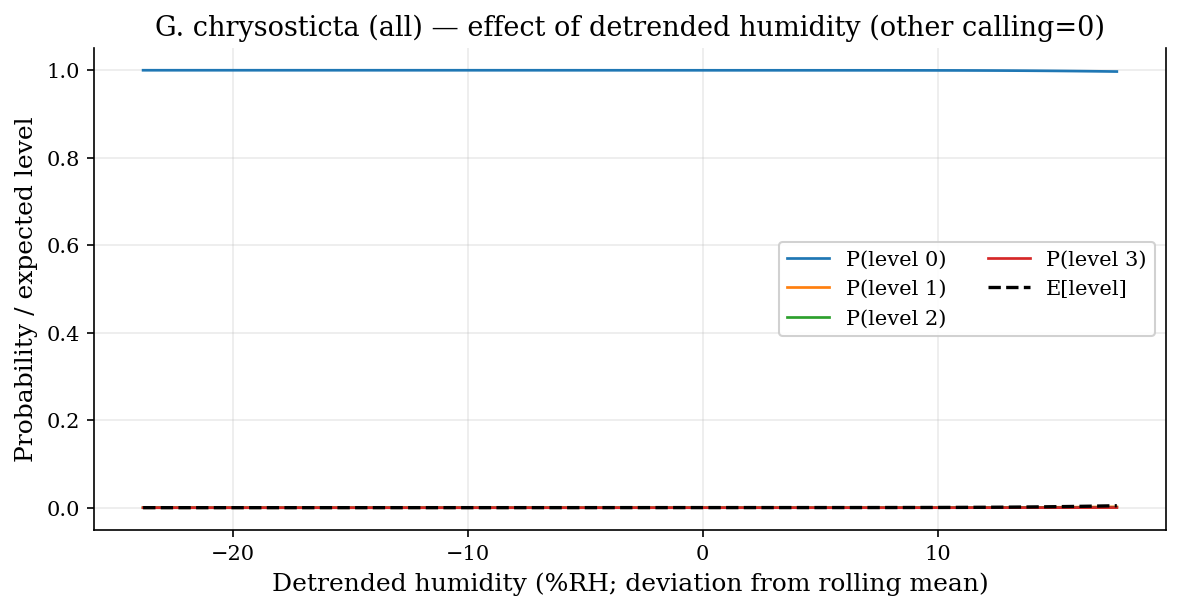

  ✓ Saved: 05_curve_temp_gastrotheca_all_other1.pdf / .svg


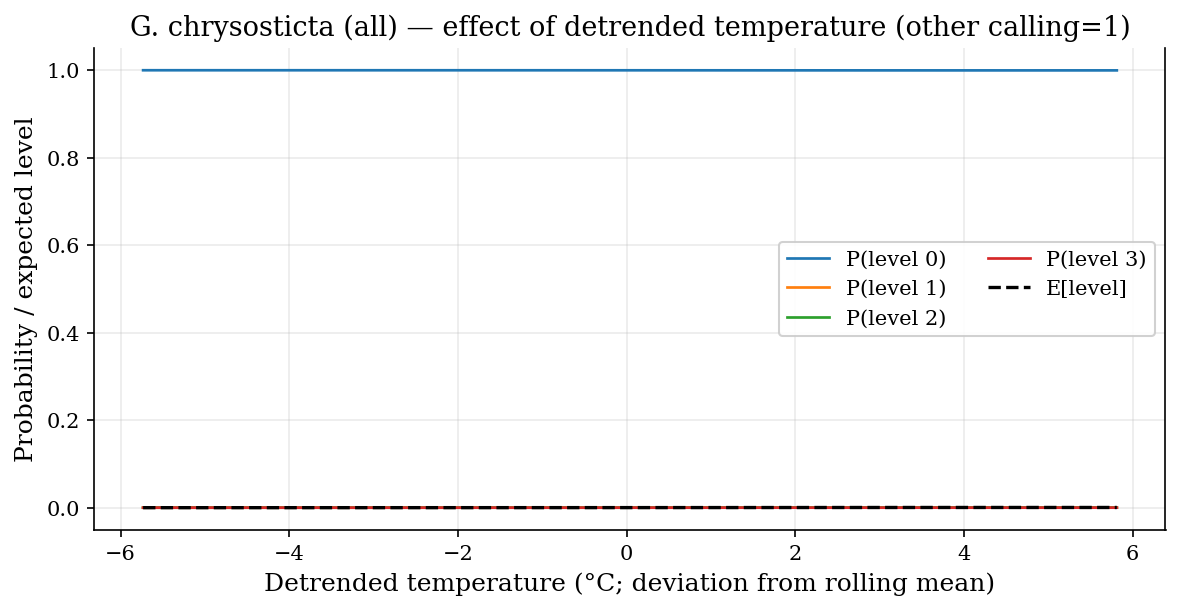

  ✓ Saved: 06_curve_rh_gastrotheca_all_other1.pdf / .svg


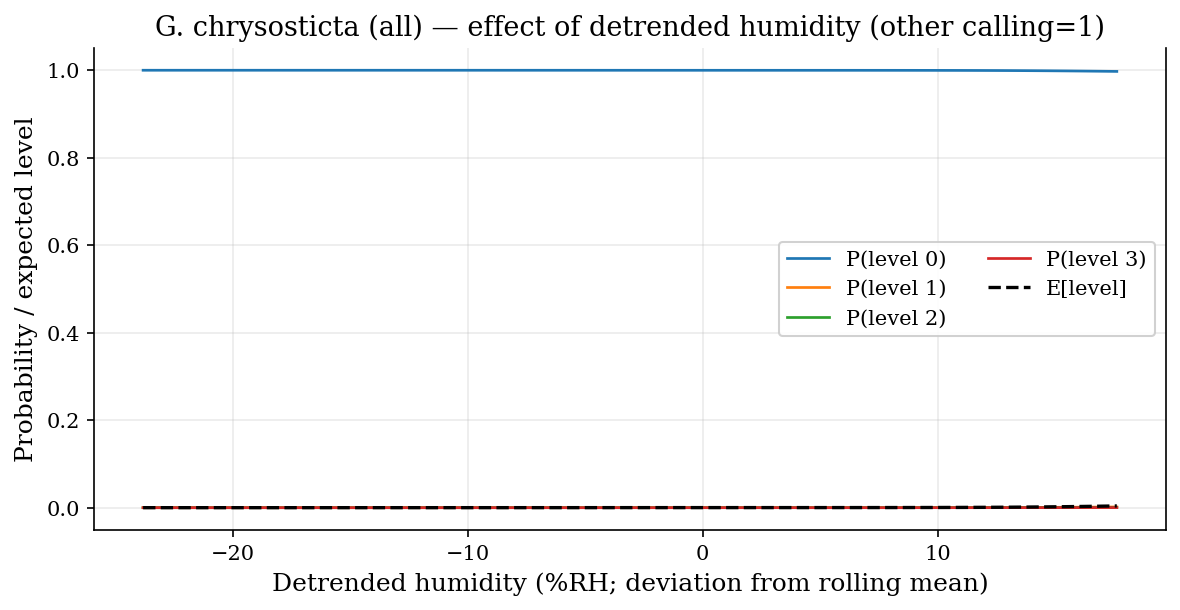

  ✓ Saved: 05_curve_temp_gastrotheca_win_other0.pdf / .svg


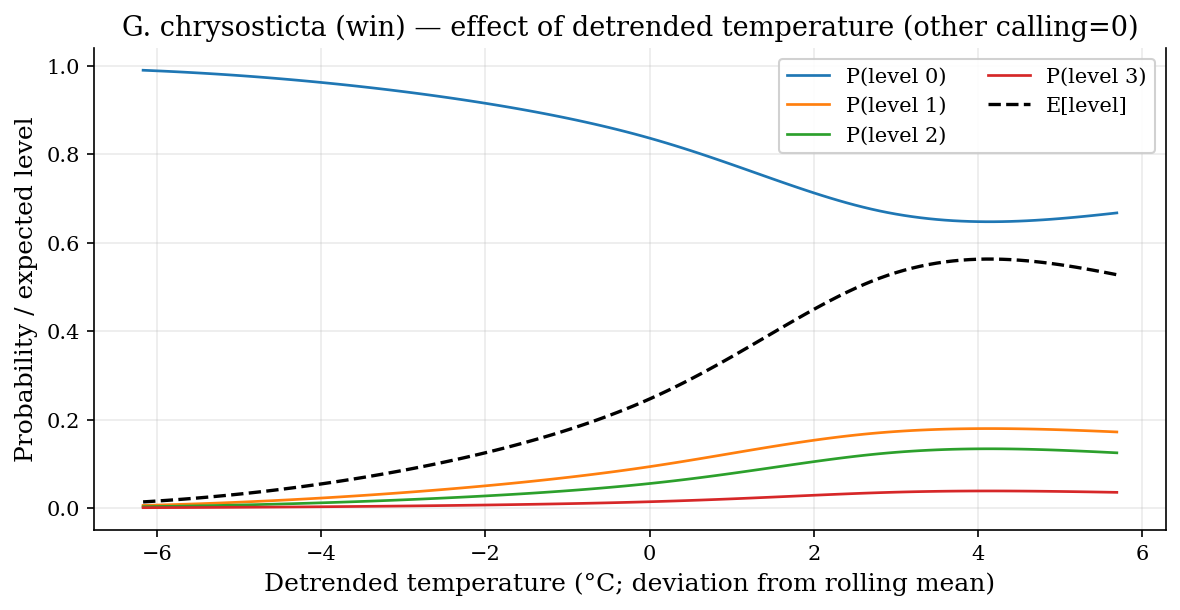

  ✓ Saved: 06_curve_rh_gastrotheca_win_other0.pdf / .svg


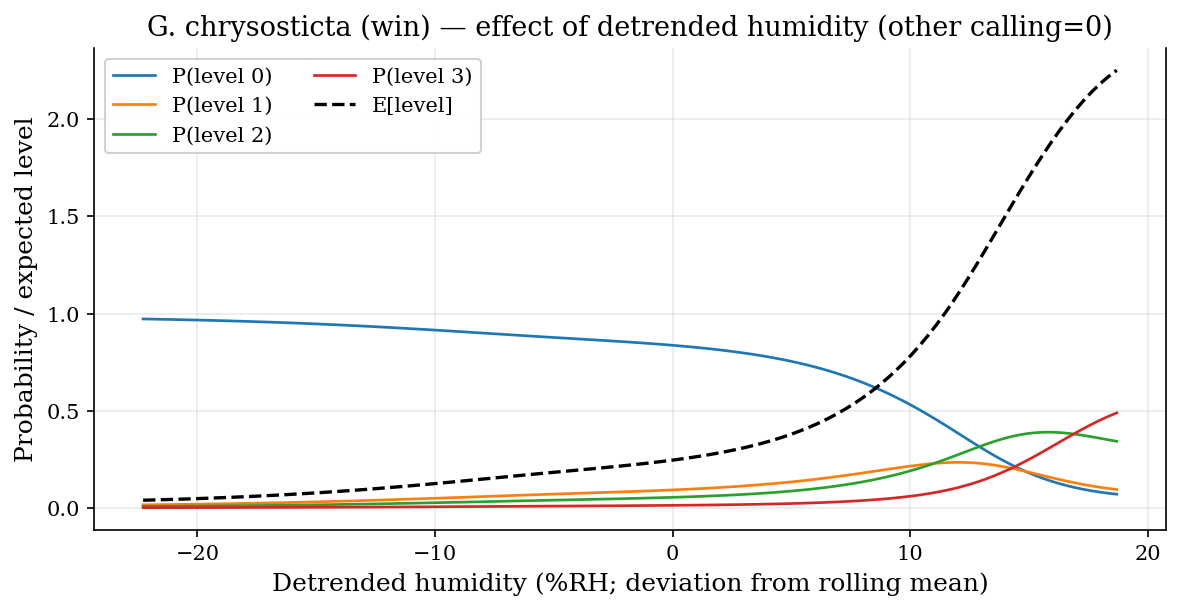

  ✓ Saved: 05_curve_temp_gastrotheca_win_other1.pdf / .svg


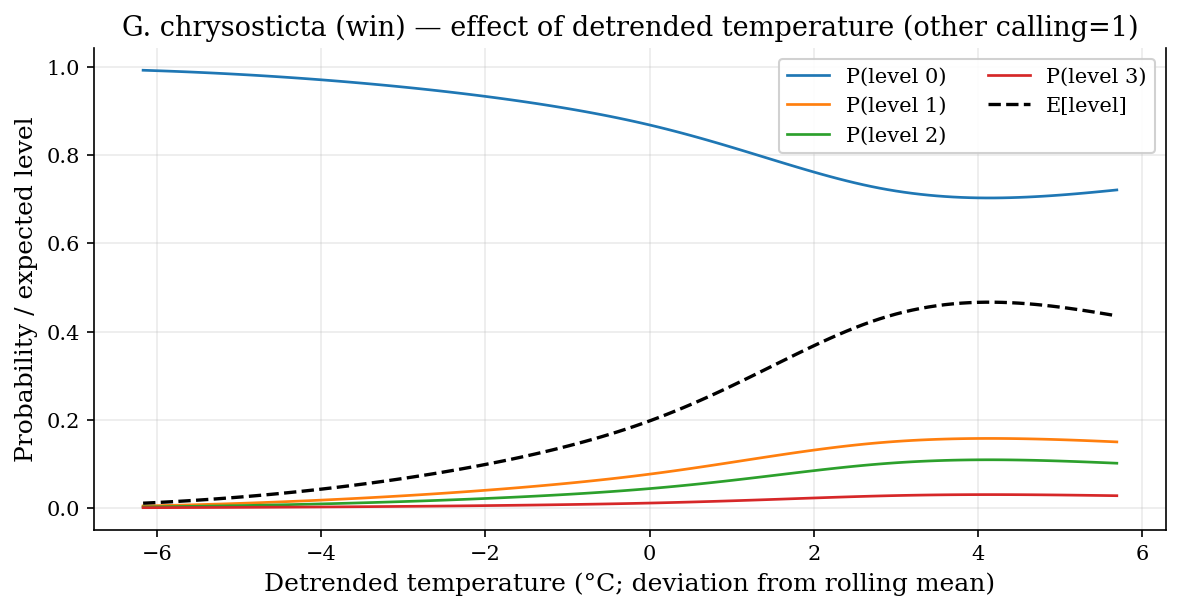

  ✓ Saved: 06_curve_rh_gastrotheca_win_other1.pdf / .svg


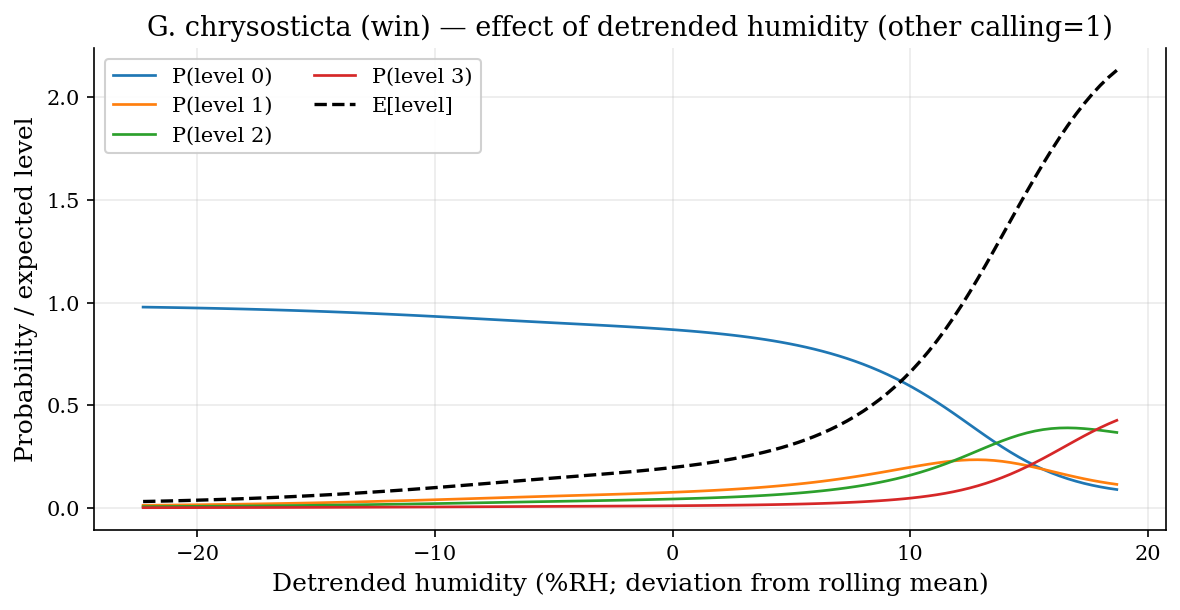

  ✓ Saved: 05_curve_temp_oreobates_all_other0.pdf / .svg


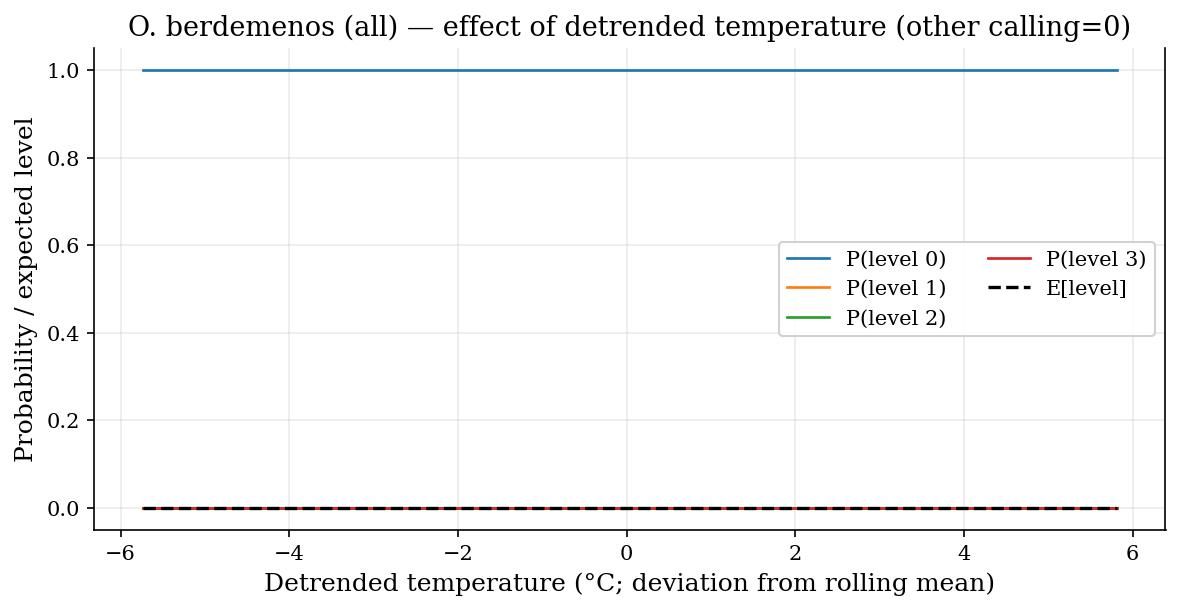

  ✓ Saved: 06_curve_rh_oreobates_all_other0.pdf / .svg


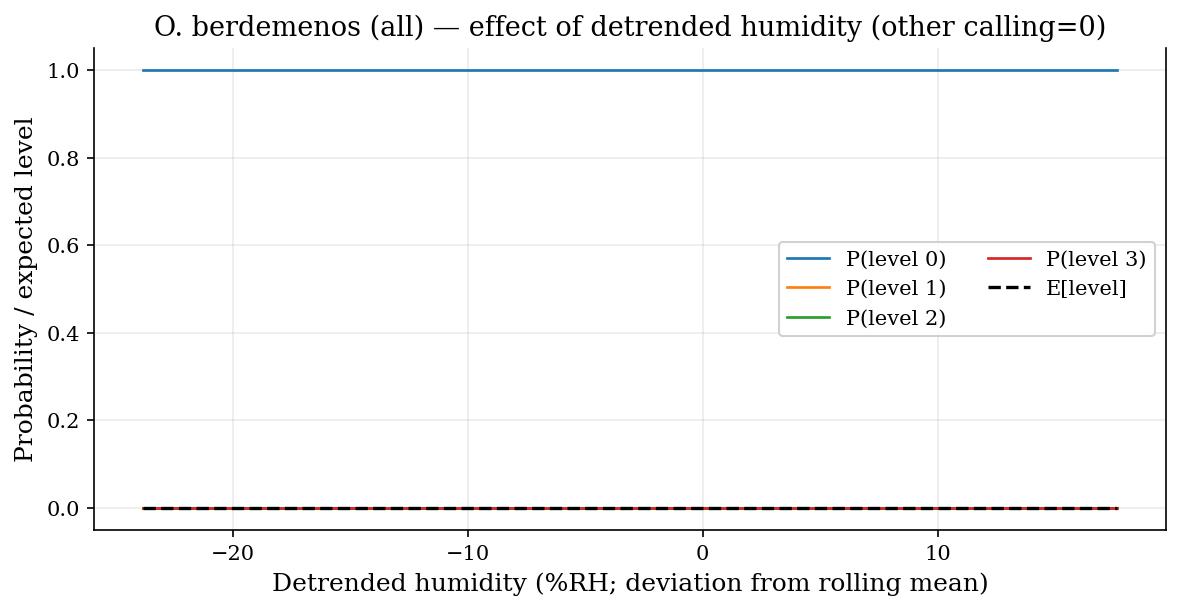

  ✓ Saved: 05_curve_temp_oreobates_all_other1.pdf / .svg


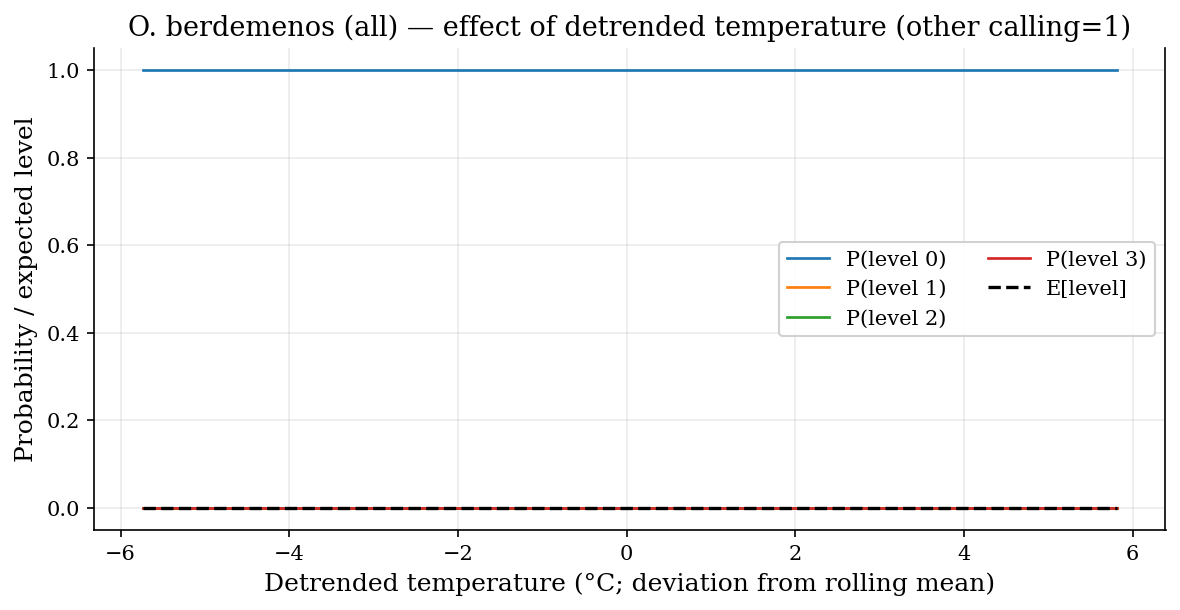

  ✓ Saved: 06_curve_rh_oreobates_all_other1.pdf / .svg


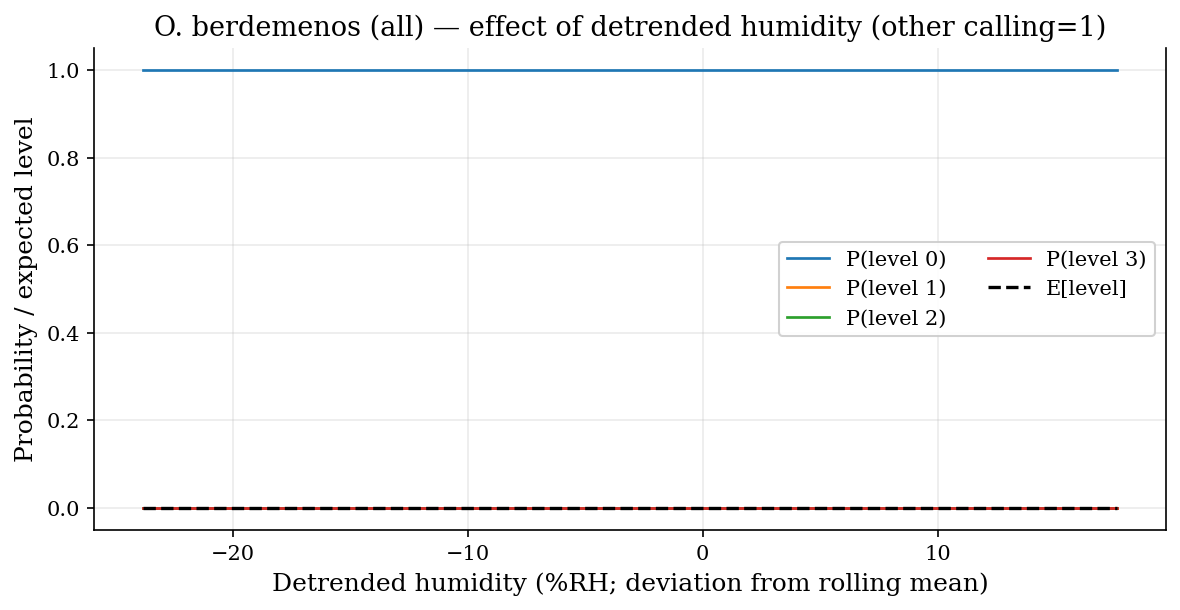

  ✓ Saved: 05_curve_temp_oreobates_win_other0.pdf / .svg


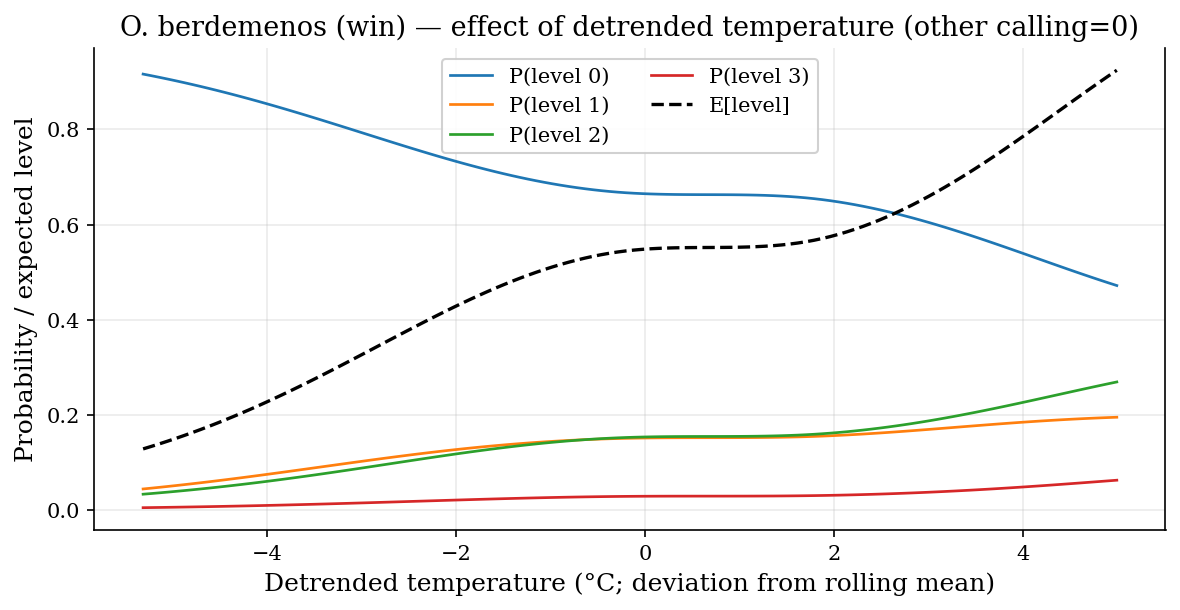

  ✓ Saved: 06_curve_rh_oreobates_win_other0.pdf / .svg


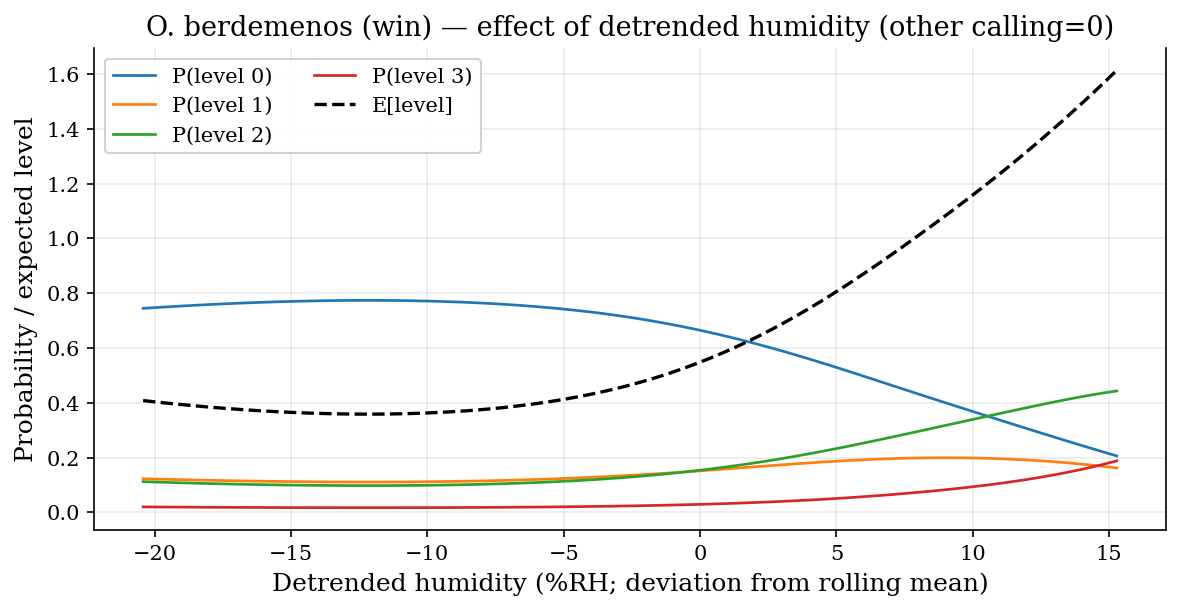

  ✓ Saved: 05_curve_temp_oreobates_win_other1.pdf / .svg


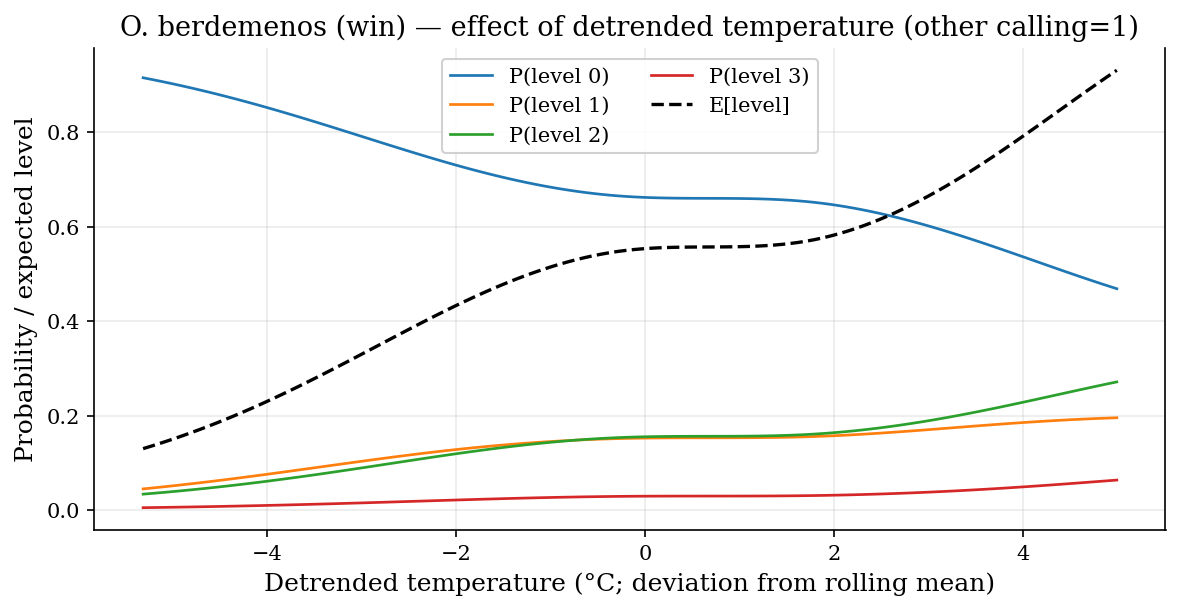

  ✓ Saved: 06_curve_rh_oreobates_win_other1.pdf / .svg


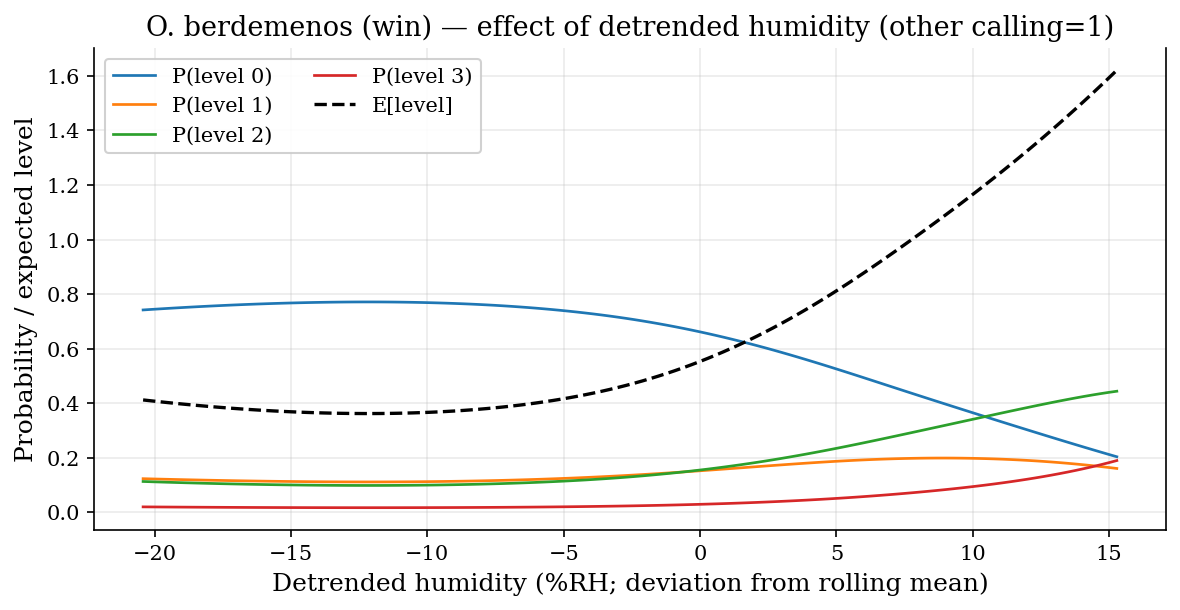

In [12]:
def fourier_terms_scalar(hour: float, doy: float):
    return {
        "sin_h1": np.sin(two_pi * hour/24.0),
        "cos_h1": np.cos(two_pi * hour/24.0),
        "sin_h2": np.sin(2*two_pi * hour/24.0),
        "cos_h2": np.cos(2*two_pi * hour/24.0),
        "sin_d1": np.sin(two_pi * doy/366.0),
        "cos_d1": np.cos(two_pi * doy/366.0),
        "sin_d2": np.sin(2*two_pi * doy/366.0),
        "cos_d2": np.cos(2*two_pi * doy/366.0),
    }

def predict_1d_curve(res, design_info, meta, var: str, grid: np.ndarray,
                     hour: float, doy: float, other_calling: int,
                     fixed_temp_detr: float = 0.0, fixed_rh_detr: float = 0.0):
    # Convert detrended raw to standardized
    temp_s = (fixed_temp_detr - meta["temp_mu"]) / meta["temp_sd"]
    rh_s = (fixed_rh_detr - meta["rh_mu"]) / meta["rh_sd"]

    rows = []
    f = fourier_terms_scalar(hour, doy)
    for x in grid:
        if var == "temp":
            t_s = (x - meta["temp_mu"]) / meta["temp_sd"]
            r_s = rh_s
        elif var == "rh":
            t_s = temp_s
            r_s = (x - meta["rh_mu"]) / meta["rh_sd"]
        else:
            raise ValueError(var)
        rows.append({"temp_detr_s": t_s, "rh_detr_s": r_s, "other_calling": other_calling, **f})

    new_df = pd.DataFrame(rows)
    Xnew = dmatrix(design_info, new_df, return_type="dataframe")
    probs = res.model.predict(res.params, exog=Xnew, which="prob")
    probs_np = np.asarray(probs)
    out = pd.DataFrame({"x": grid})
    for k in range(probs_np.shape[1]):
        out[f"p{k}"] = probs_np[:, k]
    out["E_y"] = sum(k * out[f"p{k}"] for k in range(probs_np.shape[1]))
    return out

def plot_curve(out: pd.DataFrame, xlabel: str, title: str, fname: str):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for k in [0, 1, 2, 3]:
        ax.plot(out["x"], out[f"p{k}"], linewidth=1.3, label=f"P(level {k})")
    ax.plot(out["x"], out["E_y"], linestyle="--", linewidth=1.6, color="black", label="E[level]")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Probability / expected level")
    ax.set_title(title)
    ax.legend(ncol=2, framealpha=0.9)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    savefig(fig, fname)
    plt.show()

# Choose a representative hour/doy (median hour when calling + peak doy)
for sp in SPECIES:
    for scope in ["all", "win"]:
        d = fits[sp][scope]["df"]
        # Representative conditions
        hour0 = float(d["hour"].median())
        doy0 = float(d["doy"].median())
        meta = fits[sp][scope]["meta"]
        res = fits[sp][scope]["res"]
        di = fits[sp][scope]["design"]

        # grid in raw detrended units (centered around typical)
        t_grid = np.linspace(d["Temp_detr"].quantile(0.05), d["Temp_detr"].quantile(0.95), 120)
        r_grid = np.linspace(d["RH%_detr"].quantile(0.05), d["RH%_detr"].quantile(0.95), 120)

        # other species calling set to 0 and 1
        for other in [0, 1]:
            out_t = predict_1d_curve(res, di, meta, var="temp", grid=t_grid, hour=hour0, doy=doy0, other_calling=other, fixed_rh_detr=0.0)
            plot_curve(out_t, xlabel="Detrended temperature (°C; deviation from rolling mean)",
                      title=f"{SP_SHORT[sp]} ({scope}) — effect of detrended temperature (other calling={other})",
                      fname=f"05_curve_temp_{sp.split()[0].lower()}_{scope}_other{other}")

            out_r = predict_1d_curve(res, di, meta, var="rh", grid=r_grid, hour=hour0, doy=doy0, other_calling=other, fixed_temp_detr=0.0)
            plot_curve(out_r, xlabel="Detrended humidity (%RH; deviation from rolling mean)",
                      title=f"{SP_SHORT[sp]} ({scope}) — effect of detrended humidity (other calling={other})",
                      fname=f"06_curve_rh_{sp.split()[0].lower()}_{scope}_other{other}")

## 9. Compare all-data vs expected-window fits
We compare the fitted models by computing:
- log-likelihood, AIC
- pseudo-R² (McFadden)
- and a simple in-sample $R^2$ on the expected level $E[Y]$ (treating the ordinal outcome as numeric).

## 10. Blocked time-series cross-validation (sanity check)
We want to know whether adding **Temp/RH anomalies** and **other-species calling** improves *out-of-block* prediction over a baseline that only uses time-of-day/year.

Here we do a simple blocked CV:
- split the time series into contiguous blocks (folds),
- for each fold: fit on all other blocks, evaluate on the held-out block.

Metric:
- $R^2$ on the expected level $E[Y]$ (treating ordinal as numeric) on the held-out block.

This is intentionally lightweight (fast and transparent). If you want a more formal scoring rule, we can also use mean log-likelihood on the held-out block.

In [13]:
def expected_level(res, design_info, d: pd.DataFrame):
    X = dmatrix(design_info, d, return_type="dataframe")
    probs = res.model.predict(res.params, exog=X, which="prob")
    probs_np = np.asarray(probs)
    cats = np.arange(probs_np.shape[1])
    return pd.Series((probs_np * cats).sum(axis=1), index=d.index)

def r2_expected(y: pd.Series, yhat: pd.Series):
    y = y.astype(float)
    yhat = yhat.reindex(y.index)
    sst = float(((y - y.mean())**2).sum())
    sse = float(((y - yhat)**2).sum())
    return np.nan if sst == 0 else 1.0 - sse / sst

In [14]:
def _make_block_folds(index: pd.DatetimeIndex, n_folds: int = 8):
    # contiguous blocks by time order
    order = np.argsort(index.values)
    n = len(order)
    fold_id = np.full(n, -1, dtype=int)
    # equally sized blocks
    edges = np.linspace(0, n, n_folds + 1).astype(int)
    for k in range(n_folds):
        fold_id[edges[k]:edges[k+1]] = k
    # map back to original positions
    inv = np.empty_like(order)
    inv[order] = np.arange(n)
    return fold_id[inv]

def fit_ordered_logit_from_df(d: pd.DataFrame, y_col: str):
    # re-use the existing spline_formula and OrderedModel wrapper
    X_proto = dmatrix(spline_formula, d, return_type="dataframe")
    design_info = X_proto.design_info
    X = dmatrix(design_info, d, return_type="dataframe")
    y = d[y_col].values
    mod = OrderedModel(endog=y, exog=X, distr="logit")
    res = mod.fit(method="bfgs", maxiter=2000, disp=False)
    return res, design_info

def blocked_cv_one(species: str, scope: str = "all", n_folds: int = 8, seed: int = 0):
    y_col = fits[species]["y_col"]
    base_df = fits[species][scope]["df"].copy().sort_index()
    # assign folds on available rows (after dropna)
    fold_id = _make_block_folds(base_df.index, n_folds=n_folds)

    rows = []
    for k in range(n_folds):
        train = base_df.loc[fold_id != k].copy()
        test  = base_df.loc[fold_id == k].copy()

        # Fit on train; meta (standardization) needs to be recomputed inside prep_model_df,
        # so we go back to the *raw* df and rerun prep on each split using the same columns.
        # We'll reconstruct a minimal raw frame that still contains the needed columns.
        raw_cols = [y_col, "Temp_detr", "RH%_detr", "hour", "doy",
                    "sin_h1", "cos_h1", "sin_h2", "cos_h2",
                    "sin_d1", "cos_d1", "sin_d2", "cos_d2", fits[species]["other_call_col"]]
        raw_train = df.loc[train.index, raw_cols].copy()
        raw_test  = df.loc[test.index, raw_cols].copy()

        d_tr, meta_tr = prep_model_df(raw_train, y_col=y_col, other_call_col=fits[species]["other_call_col"])
        d_te, _ = prep_model_df(raw_test,  y_col=y_col, other_call_col=fits[species]["other_call_col"])

        # If a fold ends up empty due to NA drops, skip
        if len(d_tr) < 50 or len(d_te) < 20:
            continue

        res_k, di_k = fit_ordered_logit_from_df(d_tr, y_col=y_col)
        yhat = expected_level(res_k, di_k, d_te)
        r2 = r2_expected(d_te[y_col], yhat)

        rows.append({
            "fold": k,
            "n_train": int(len(d_tr)),
            "n_test": int(len(d_te)),
            "r2_expected": float(r2),
        })

    return pd.DataFrame(rows)

# Run blocked CV and plot results
cv_rows = []
for sp in SPECIES:
    for scope in ["all", "win"]:
        out = blocked_cv_one(sp, scope=scope, n_folds=8)
        out["species"] = sp
        out["scope"] = scope
        cv_rows.append(out)

cv = pd.concat(cv_rows, ignore_index=True)
cv.head()

PatsyError: Error evaluating factor: NotImplementedError: some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
    0 + bs(temp_detr_s, df=6, degree=3) + bs(rh_detr_s, df=6, degree=3) + sin_h1 + cos_h1 + sin_h2 + cos_h2 + sin_d1 + cos_d1 + sin_d2 + cos_d2 + other_calling
                                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
# Plot blocked CV R2 by fold
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
for ax, scope, ttl in zip(axes, ["all", "win"], ["All data", "Expected window"]):
    for sp in SPECIES:
        dd = cv[(cv["species"] == sp) & (cv["scope"] == scope)].sort_values("fold")
        ax.plot(dd["fold"], dd["r2_expected"], marker="o", linewidth=1.8, color=SP_COLOR[sp], label=SP_SHORT[sp])
    ax.axhline(0, color="black", linewidth=1, alpha=0.4)
    ax.set_title(ttl)
    ax.set_xlabel("Held-out block (fold)")
    ax.set_xticks(sorted(cv[cv["scope"] == scope]["fold"].unique()))
    ax.grid(alpha=0.2)
axes[0].set_ylabel(r"$R^2$ on $E[Y]$ (held-out)")
axes[0].legend(framealpha=0.9)
fig.suptitle("Blocked time-series CV: predictive skill by held-out time block", fontsize=14)
fig.tight_layout()
savefig(fig, "08_blocked_cv_r2")
plt.show()

## 11. Joint model with shared latent variables (both species together)
`statsmodels` doesn’t currently offer a true *multivariate ordinal* model with shared latent factors.

But we can still get most of what you want — "both species share latent variables" — with a practical approximation:
- create a **shared latent activity index** from the *detrended* call series (first principal component),
- include that shared latent index as a covariate in each species’ ordinal model (plus a species-specific residual component if useful).

Interpretation: the shared factor captures unobserved drivers that affect both species (e.g., unmeasured rainfall, moonlight, observer variance, habitat noise), while the remaining model terms capture *species-specific* sensitivity to Temp/RH anomalies and to the other species calling.

If you’d prefer a fully generative joint model (multivariate ordinal with shared random effects), the natural next step is a Bayesian model (e.g., PyMC). I can add that too, but it’ll add runtime and dependencies.

In [ ]:
# Build shared latent factor from detrended calls
call_cols = ["Gastrotheca chrysosticta_detr", "Oreobates berdemenos_detr"]
Z = df[call_cols].dropna().copy()

# Standardize each series before PCA
Zs = (Z - Z.mean()) / Z.std(ddof=0)
U, S, Vt = np.linalg.svd(Zs.to_numpy(), full_matrices=False)
pc1 = U[:, 0] * S[0]
df.loc[Z.index, "latent_shared_pc1"] = pc1

# Optional: scale to unit variance for interpretability
m = df["latent_shared_pc1"].mean()
s = df["latent_shared_pc1"].std(ddof=0)
df["latent_shared_pc1_s"] = (df["latent_shared_pc1"] - m) / (s if s > 0 else 1.0)

df[["latent_shared_pc1_s"]].describe()

In [ ]:
# Refit ordinal models including shared latent factor
spline_formula_joint = (
    "0 + bs(temp_detr_s, df=6, degree=3) + bs(rh_detr_s, df=6, degree=3) "
    "+ sin_h1 + cos_h1 + sin_h2 + cos_h2 "
    "+ sin_d1 + cos_d1 + sin_d2 + cos_d2 "
    "+ other_calling + latent_shared"
 )

def prep_model_df_joint(df_in: pd.DataFrame, y_col: str, other_call_col: str) -> tuple[pd.DataFrame, dict]:
    d, meta = prep_model_df(df_in, y_col=y_col, other_call_col=other_call_col)
    d = d.dropna(subset=["latent_shared_pc1_s"]).copy()
    d["latent_shared"] = d["latent_shared_pc1_s"].astype(float)
    return d, meta

def fit_ordered_logit_joint(d: pd.DataFrame, y_col: str):
    X_proto = dmatrix(spline_formula_joint, d, return_type="dataframe")
    design_info = X_proto.design_info
    X = dmatrix(design_info, d, return_type="dataframe")
    y = d[y_col].values
    mod = OrderedModel(endog=y, exog=X, distr="logit")
    res = mod.fit(method="bfgs", maxiter=2000, disp=False)
    return res, design_info

def fit_two_scopes_joint(species: str):
    y_col = fits[species]["y_col"]
    expected_col = fits[species]["expected_col"]
    other_call_col = fits[species]["other_call_col"]

    d_all, meta_all = prep_model_df_joint(df, y_col=y_col, other_call_col=other_call_col)
    res_all, di_all = fit_ordered_logit_joint(d_all, y_col=y_col)

    d_win_src = df.loc[df[expected_col].astype(bool)].copy()
    d_win, meta_win = prep_model_df_joint(d_win_src, y_col=y_col, other_call_col=other_call_col)
    res_win, di_win = fit_ordered_logit_joint(d_win, y_col=y_col)

    return {
        "y_col": y_col,
        "expected_col": expected_col,
        "other_call_col": other_call_col,
        "all": {"res": res_all, "design": di_all, "df": d_all, "meta": meta_all},
        "win": {"res": res_win, "design": di_win, "df": d_win, "meta": meta_win},
    }

fits_joint = {sp: fit_two_scopes_joint(sp) for sp in SPECIES}
for sp in SPECIES:
    print("\n" + "="*90)
    print(sp, "(JOINT + shared latent; ALL DATA)")
    print(fits_joint[sp]["all"]["res"].summary())

In [ ]:


rows = []
for sp in SPECIES:
    y_col = fits[sp]["y_col"]
    for scope in ["all", "win"]:
        res = fits[sp][scope]["res"]
        di = fits[sp][scope]["design"]
        d = fits[sp][scope]["df"]

        y = d[y_col]
        yhat = expected_level(res, di, d)

        rows.append({
            "species": sp,
            "scope": scope,
            "n": int(len(d)),
            "llf": float(res.llf),
            "aic": float(res.aic),
            "mcfadden_r2": float(res.prsquared) if hasattr(res, "prsquared") else np.nan,
            "r2_expected": float(r2_expected(y, yhat)),
        })

cmp = pd.DataFrame(rows)
cmp

,species,scope,n,llf,aic,mcfadden_r2,r2_expected
0,Gastrotheca chrysosticta,all,11303,-2756.658091,5561.316181,0.389097,0.469743
1,Gastrotheca chrysosticta,win,2301,-2207.466080,4462.932160,0.141010,0.317708
2,Oreobates berdemenos,all,11303,-2107.523682,4263.047364,0.406245,0.393300
3,Oreobates berdemenos,win,1627,-1586.560006,3221.120012,0.089634,0.196756


  ✓ Saved: 07_model_compare_aic.pdf / .svg


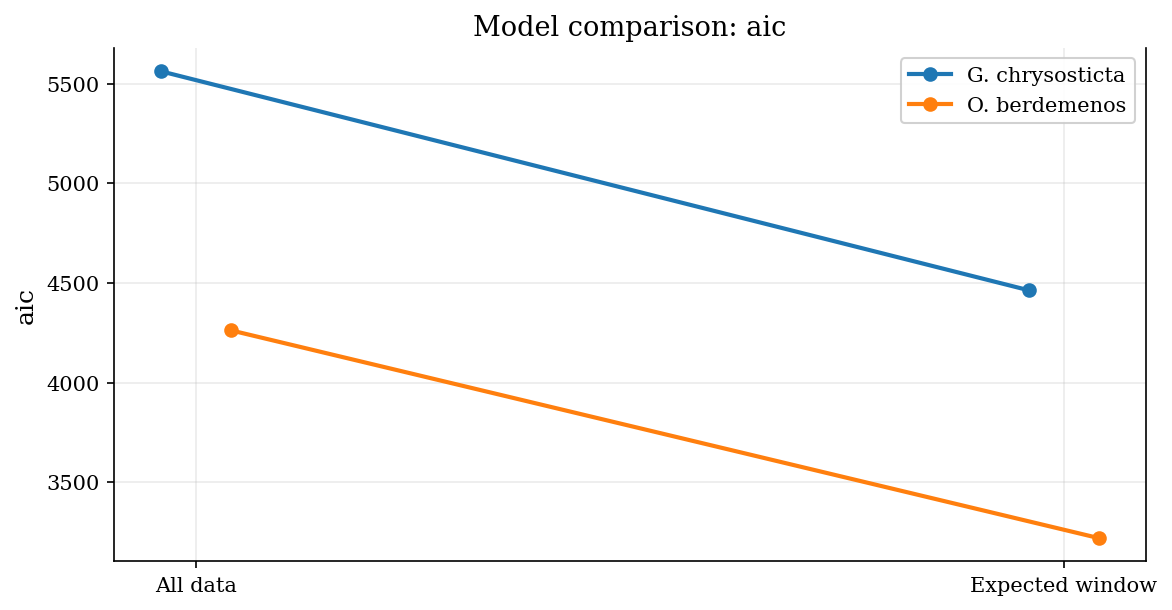

  ✓ Saved: 07_model_compare_r2_expected.pdf / .svg


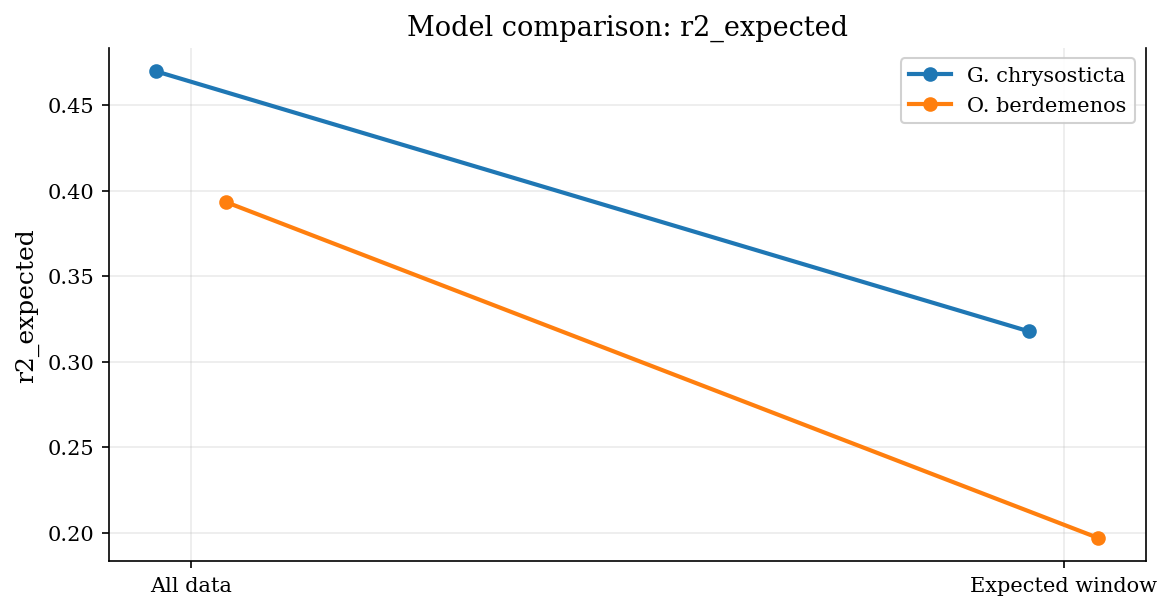

In [ ]:
# Plot comparison (AIC and R2_expected)
for metric in ["aic", "r2_expected"]:
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for i, sp in enumerate(SPECIES):
        sub = cmp[cmp["species"] == sp].set_index("scope").loc[["all", "win"]]
        xs = np.array([0, 1]) + (i - 0.5) * 0.08
        ax.plot(xs, sub[metric].values, marker="o", linewidth=2.0, color=SP_COLOR[sp], label=SP_SHORT[sp])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["All data", "Expected window"])
    ax.set_title(f"Model comparison: {metric}")
    ax.set_ylabel(metric)
    ax.legend(framealpha=0.9)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    savefig(fig, f"07_model_compare_{metric}")
    plt.show()

## Notes / next steps
- If you want the expected-calling window to match a biologically-defined rule (e.g., specific months/hours), replace the data-driven mask in Section 4 with those rules.
- You can also switch the detrending window (Section 3) or perform detrending on daily aggregates and map back to hourly.
- If you’d like, we can add partial dependence / ALE plots for detrended covariates (the `Granger.ipynb` notebook contains an ALE implementation).